✓ All libraries imported successfully
SMART GRID ENERGY FORECASTING & ANOMALY DETECTION SYSTEM
With R² Accuracy Metrics
✓ Dataset already downloaded

Loading UCI Household Power Consumption Dataset...
✓ Raw data loaded: 474160 records
✓ After cleaning: 470227 records
✓ After removing infinities: 470227 records
✓ Resampled to hourly: 7842 records
✓ Using FULL dataset: 7842 samples
✓ Final dataset after outlier removal: (7842, 5)
  Features: ['consumption', 'reactive_power', 'voltage', 'hour', 'day_of_week']

  Data ranges:
       consumption  reactive_power      voltage         hour  day_of_week
count  7842.000000     7842.000000  7842.000000  7842.000000  7842.000000
mean      1.088452        0.120034   239.130443    11.512879     2.992094
std       0.987386        0.065828     3.275276     6.927018     1.994045
min       0.138733        0.021033   225.834500     0.000000     0.000000
25%       0.290533        0.075867   236.821250     6.000000     1.000000
50%       0.718617        0.

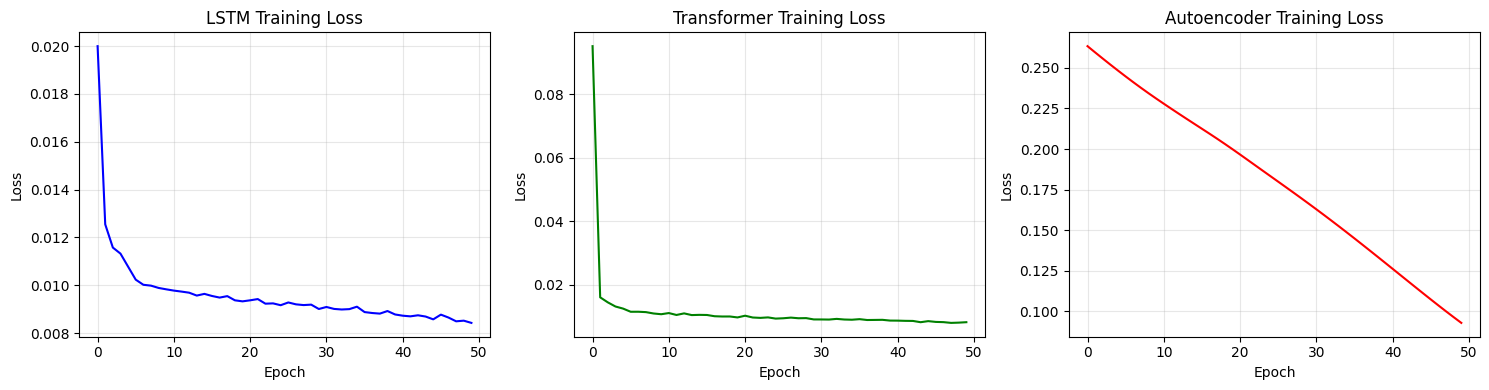


R² Score Evolution:


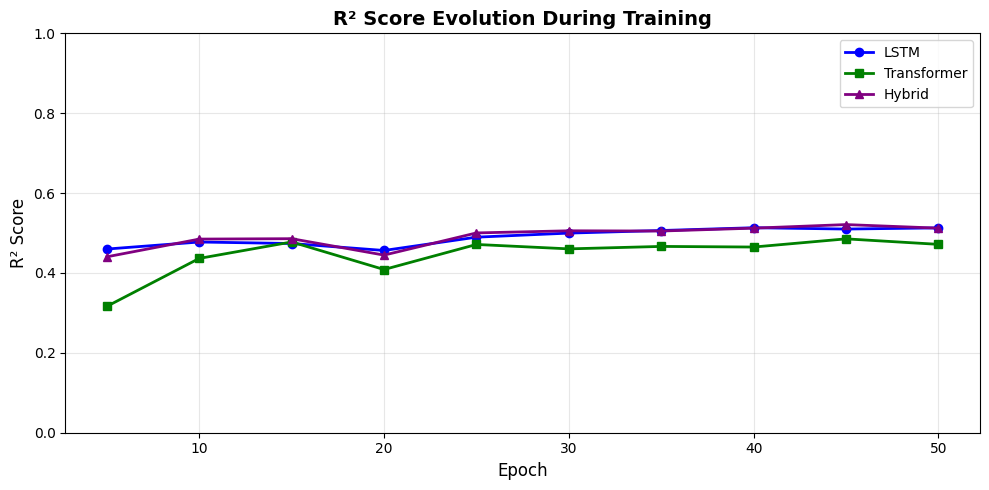


MODEL EVALUATION METRICS

LSTM Model:
  R² Score:  0.5848
  MAE:       0.0683
  MSE:       0.0100
  RMSE:      0.0998

Transformer Model:
  R² Score:  0.5660
  MAE:       0.0681
  MSE:       0.0104
  RMSE:      0.1020

Hybrid Model:
  R² Score:  0.5957
  MAE:       0.0663
  MSE:       0.0097
  RMSE:      0.0985

TESTING UNIFIED FRAMEWORK - Sample Predictions

Sample 1:
  Predicted: 0.22 kW
  Actual: 0.16 kW
  Error: 0.06 kW
  Anomaly: 🚨 YES
  Reconstruction Error: 0.2458

Sample 2:
  Predicted: 1.65 kW
  Actual: 3.48 kW
  Error: 1.83 kW
  Anomaly: 🚨 YES
  Reconstruction Error: 0.0677

Sample 3:
  Predicted: 0.70 kW
  Actual: 0.76 kW
  Error: 0.06 kW
  Anomaly: 🚨 YES
  Reconstruction Error: 0.0316

Sample 4:
  Predicted: 1.51 kW
  Actual: 1.67 kW
  Error: 0.17 kW
  Anomaly: 🚨 YES
  Reconstruction Error: 0.0272

Sample 5:
  Predicted: 1.65 kW
  Actual: 2.97 kW
  Error: 1.31 kW
  Anomaly: 🚨 YES
  Reconstruction Error: 0.0441


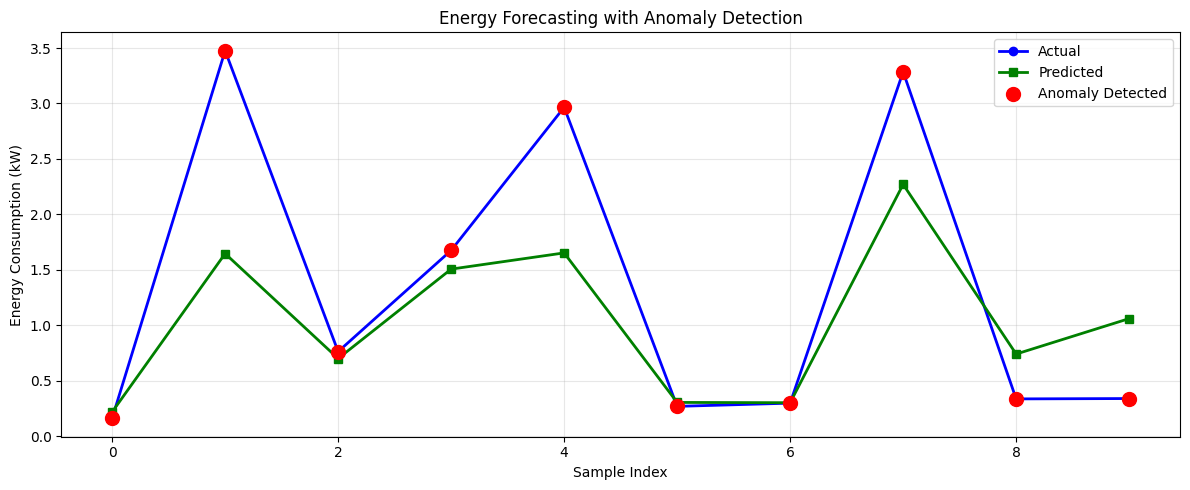


MODEL PERFORMANCE SUMMARY

🏆 Best Model: Hybrid
   R² Score: 0.5957
   RMSE: 0.0985

✅ SYSTEM IMPLEMENTATION COMPLETE


In [ ]:
# Smart Grid Energy Forecasting & Anomaly Detection System
# Optimized for Google Colab with R² Accuracy Metrics

# ============================================================================
# STEP 1: Install and Import Dependencies
# ============================================================================

# Install required packages (uncomment if needed)
# !pip install torch pandas scikit-learn numpy matplotlib

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

# ============================================================================
# STEP 2: Download Dataset (Automatic)
# ============================================================================

def download_dataset():
    """Download UCI Household Power Consumption dataset"""
    import os

    # Check if file already exists
    if os.path.exists('household_power_consumption.txt'):
        print("✓ Dataset already downloaded")
        return True

    print("Downloading UCI Household Power Consumption Dataset...")
    print("Note: You can also download manually from:")
    print("https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set")

    try:
        # Try to download from UCI repository
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
        import urllib.request
        import zipfile

        print("Downloading... (this may take a few minutes)")
        urllib.request.urlretrieve(url, "household_power_consumption.zip")

        print("Extracting...")
        with zipfile.ZipFile("household_power_consumption.zip", 'r') as zip_ref:
            zip_ref.extractall(".")

        print("✓ Dataset downloaded and extracted successfully")
        return True
    except Exception as e:
        print(f"Could not auto-download: {e}")
        print("\nAlternative: Upload the file manually to Colab")
        print("1. Download from Kaggle")
        print("2. Click the folder icon on the left sidebar")
        print("3. Upload household_power_consumption.txt")
        return False

# ============================================================================
# STEP 3: Model Definitions
# ============================================================================

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super(TransformerForecaster, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        out = self.fc(out[:, -1, :])
        return out

class Autoencoder(nn.Module):
    def __init__(self, input_size):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_size)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=24):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ============================================================================
# STEP 4: Data Loading Functions
# ============================================================================

def load_uci_dataset(filepath='household_power_consumption.txt', sample_size=None):
    """Load and preprocess UCI dataset"""
    print("\n" + "="*70)
    print("Loading UCI Household Power Consumption Dataset...")
    print("="*70)

    try:
        df = pd.read_csv(filepath, sep=';', parse_dates={'datetime': ['Date', 'Time']},
                         infer_datetime_format=True, low_memory=False, na_values=['?'])

        print(f"✓ Raw data loaded: {len(df)} records")

        # Clean data more robustly
        df = df.replace('?', np.nan)
        for col in df.columns:
            if col != 'datetime':
                df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df.dropna()
        df = df.set_index('datetime')
        print(f"✓ After cleaning: {len(df)} records")

        # Remove any infinite values
        df = df.replace([np.inf, -np.inf], np.nan).dropna()
        print(f"✓ After removing infinities: {len(df)} records")

        # Resample to hourly for efficiency
        df_resampled = df.resample('H').mean()
        df_resampled = df_resampled.dropna()
        print(f"✓ Resampled to hourly: {len(df_resampled)} records")

        # Use full dataset (no sampling)
        print(f"✓ Using FULL dataset: {len(df_resampled)} samples")

        # Add temporal features
        df_resampled['hour'] = df_resampled.index.hour
        df_resampled['day_of_week'] = df_resampled.index.dayofweek

        # Select features
        feature_cols = ['Global_active_power', 'Global_reactive_power',
                       'Voltage', 'hour', 'day_of_week']
        df_processed = df_resampled[feature_cols].copy()
        df_processed.columns = ['consumption', 'reactive_power', 'voltage', 'hour', 'day_of_week']

        # Final NaN check
        df_processed = df_processed.dropna()

        # Remove outliers using IQR method for stability
        for col in ['consumption', 'reactive_power', 'voltage']:
            Q1 = df_processed[col].quantile(0.01)
            Q3 = df_processed[col].quantile(0.99)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            df_processed = df_processed[(df_processed[col] >= lower_bound) & (df_processed[col] <= upper_bound)]

        print(f"✓ Final dataset after outlier removal: {df_processed.shape}")
        print(f"  Features: {list(df_processed.columns)}")
        print(f"\n  Data ranges:")
        print(df_processed.describe())

        return df_processed.reset_index(drop=True)

    except FileNotFoundError:
        print("❌ File not found. Please upload the dataset to Colab.")
        return None
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None

def generate_synthetic_data(n_samples=2000):
    """Generate synthetic smart grid data"""
    print("\n" + "="*70)
    print("Generating Synthetic Smart Grid Data...")
    print("="*70)

    np.random.seed(42)
    time = np.arange(n_samples)

    daily_pattern = 50 + 30 * np.sin(2 * np.pi * time / 24)
    weekly_pattern = 10 * np.sin(2 * np.pi * time / (24 * 7))
    temperature = 20 + 10 * np.sin(2 * np.pi * time / (24 * 365)) + np.random.normal(0, 2, n_samples)
    weather_effect = 0.5 * temperature
    occupancy = 0.7 + 0.3 * np.sin(2 * np.pi * time / 24) + np.random.normal(0, 0.05, n_samples)
    occupancy = np.clip(occupancy, 0, 1)
    occupancy_effect = 20 * occupancy

    consumption = daily_pattern + weekly_pattern + weather_effect + occupancy_effect + np.random.normal(0, 3, n_samples)

    # Add anomalies
    anomaly_indices = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    consumption[anomaly_indices] += np.random.uniform(30, 60, len(anomaly_indices)) * np.random.choice([-1, 1], len(anomaly_indices))

    df = pd.DataFrame({
        'consumption': consumption,
        'temperature': temperature,
        'occupancy': occupancy,
        'hour': time % 24,
        'day_of_week': (time // 24) % 7
    })

    print(f"✓ Generated {len(df)} samples with {len(df.columns)} features")
    return df

# ============================================================================
# STEP 5: Smart Grid System with R² Metrics
# ============================================================================

class SmartGridSystem:
    def __init__(self, input_size=5, seq_length=24):
        self.seq_length = seq_length
        self.scaler = MinMaxScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✓ Using device: {self.device}")

        # Forecasting models
        self.lstm_model = LSTMForecaster(input_size).to(self.device)
        self.transformer_model = TransformerForecaster(input_size).to(self.device)

        # Anomaly detection models
        self.autoencoder = Autoencoder(input_size).to(self.device)
        self.isolation_forest = IsolationForest(contamination=0.05, random_state=42)

        self.criterion = nn.MSELoss()
        self.train_losses = {'lstm': [], 'transformer': [], 'autoencoder': []}

        # R² tracking for validation
        self.r2_scores = {'lstm': [], 'transformer': [], 'hybrid': []}

    def prepare_data(self, df):
        data = df.values
        scaled_data = self.scaler.fit_transform(data)
        return scaled_data

    def calculate_r2_on_validation(self, val_data, model_type='lstm'):
        """Calculate R² score on validation data"""
        self.lstm_model.eval()
        self.transformer_model.eval()

        predictions = []
        actuals = []

        with torch.no_grad():
            for i in range(len(val_data) - self.seq_length):
                x = torch.FloatTensor(val_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                y_actual = val_data[i+self.seq_length, 0]

                if model_type == 'lstm':
                    pred = self.lstm_model(x).cpu().item()
                elif model_type == 'transformer':
                    pred = self.transformer_model(x).cpu().item()
                else:  # hybrid
                    pred_lstm = self.lstm_model(x).cpu().item()
                    pred_transformer = self.transformer_model(x).cpu().item()
                    pred = (pred_lstm + pred_transformer) / 2

                predictions.append(pred)
                actuals.append(y_actual)

        r2 = r2_score(actuals, predictions)
        return r2

    def train_forecasting(self, data, epochs=20, lr=0.001, batch_size=32, val_data=None):
        dataset = TimeSeriesDataset(data, self.seq_length)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        optimizer_lstm = torch.optim.Adam(self.lstm_model.parameters(), lr=lr)
        optimizer_transformer = torch.optim.Adam(self.transformer_model.parameters(), lr=lr)

        print("\n" + "="*70)
        print("Training Forecasting Models (LSTM + Transformer)...")
        print("="*70)

        for epoch in range(epochs):
            total_loss_lstm = 0
            total_loss_transformer = 0

            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                # LSTM training
                optimizer_lstm.zero_grad()
                pred_lstm = self.lstm_model(x)
                loss_lstm = self.criterion(pred_lstm, y)
                loss_lstm.backward()
                optimizer_lstm.step()
                total_loss_lstm += loss_lstm.item()

                # Transformer training
                optimizer_transformer.zero_grad()
                pred_transformer = self.transformer_model(x)
                loss_transformer = self.criterion(pred_transformer, y)
                loss_transformer.backward()
                optimizer_transformer.step()
                total_loss_transformer += loss_transformer.item()

            avg_loss_lstm = total_loss_lstm / len(loader)
            avg_loss_transformer = total_loss_transformer / len(loader)
            self.train_losses['lstm'].append(avg_loss_lstm)
            self.train_losses['transformer'].append(avg_loss_transformer)

            # Calculate R² scores on validation data every 5 epochs
            if val_data is not None and (epoch + 1) % 5 == 0:
                r2_lstm = self.calculate_r2_on_validation(val_data, 'lstm')
                r2_transformer = self.calculate_r2_on_validation(val_data, 'transformer')
                r2_hybrid = self.calculate_r2_on_validation(val_data, 'hybrid')

                self.r2_scores['lstm'].append(r2_lstm)
                self.r2_scores['transformer'].append(r2_transformer)
                self.r2_scores['hybrid'].append(r2_hybrid)

                print(f"Epoch {epoch+1}/{epochs}:")
                print(f"  LSTM Loss={avg_loss_lstm:.4f}, R²={r2_lstm:.4f}")
                print(f"  Transformer Loss={avg_loss_transformer:.4f}, R²={r2_transformer:.4f}")
                print(f"  Hybrid R²={r2_hybrid:.4f}")

    def train_anomaly_detection(self, data, epochs=20, lr=0.001):
        print("\n" + "="*70)
        print("Training Anomaly Detection Models (Autoencoder + Isolation Forest)...")
        print("="*70)

        # Train Autoencoder
        data_tensor = torch.FloatTensor(data).to(self.device)
        optimizer = torch.optim.Adam(self.autoencoder.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            reconstructed = self.autoencoder(data_tensor)
            loss = self.criterion(reconstructed, data_tensor)
            loss.backward()
            optimizer.step()

            self.train_losses['autoencoder'].append(loss.item())

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs}: Autoencoder Loss={loss.item():.4f}")

        # Train Isolation Forest
        self.isolation_forest.fit(data)
        print("✓ Isolation Forest trained")

    def forecast(self, data):
        self.lstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            x = torch.FloatTensor(data[-self.seq_length:]).unsqueeze(0).to(self.device)
            pred_lstm = self.lstm_model(x).cpu().item()
            pred_transformer = self.transformer_model(x).cpu().item()
            hybrid_pred = (pred_lstm + pred_transformer) / 2

        return hybrid_pred, pred_lstm, pred_transformer

    def detect_anomalies(self, data_point):
        with torch.no_grad():
            x = torch.FloatTensor(data_point).unsqueeze(0).to(self.device)
            reconstructed = self.autoencoder(x)
            reconstruction_error = torch.mean((x - reconstructed) ** 2).cpu().item()

        iso_prediction = self.isolation_forest.predict([data_point])[0]
        is_anomaly_iso = iso_prediction == -1

        threshold = 0.01
        is_anomaly = reconstruction_error > threshold or is_anomaly_iso

        return is_anomaly, reconstruction_error

    def adaptive_forecast_with_anomaly(self, data):
        hybrid_pred, _, _ = self.forecast(data)
        recent_data = data[-1]
        is_anomaly, error = self.detect_anomalies(recent_data)

        if is_anomaly:
            adjustment_factor = 0.9
            adjusted_pred = hybrid_pred * adjustment_factor
            return adjusted_pred, is_anomaly, error

        return hybrid_pred, is_anomaly, error

    def evaluate_models(self, test_data):
        """Comprehensive model evaluation with R² and other metrics"""
        print("\n" + "="*70)
        print("MODEL EVALUATION METRICS")
        print("="*70)

        predictions_lstm = []
        predictions_transformer = []
        predictions_hybrid = []
        actuals = []

        self.lstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            for i in range(len(test_data) - self.seq_length):
                x = torch.FloatTensor(test_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                y_actual = test_data[i+self.seq_length, 0]

                pred_lstm = self.lstm_model(x).cpu().item()
                pred_transformer = self.transformer_model(x).cpu().item()
                pred_hybrid = (pred_lstm + pred_transformer) / 2

                predictions_lstm.append(pred_lstm)
                predictions_transformer.append(pred_transformer)
                predictions_hybrid.append(pred_hybrid)
                actuals.append(y_actual)

        # Calculate metrics for each model
        models = {
            'LSTM': predictions_lstm,
            'Transformer': predictions_transformer,
            'Hybrid': predictions_hybrid
        }

        results = {}
        for model_name, preds in models.items():
            r2 = r2_score(actuals, preds)
            mae = mean_absolute_error(actuals, preds)
            mse = mean_squared_error(actuals, preds)
            rmse = np.sqrt(mse)

            results[model_name] = {
                'R²': r2,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse
            }

            print(f"\n{model_name} Model:")
            print(f"  R² Score:  {r2:.4f}")
            print(f"  MAE:       {mae:.4f}")
            print(f"  MSE:       {mse:.4f}")
            print(f"  RMSE:      {rmse:.4f}")

        return results, actuals, predictions_hybrid

    def plot_training_losses(self):
        """Plot training losses"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.train_losses['lstm'], label='LSTM', color='blue')
        axes[0].set_title('LSTM Training Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.train_losses['transformer'], label='Transformer', color='green')
        axes[1].set_title('Transformer Training Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(self.train_losses['autoencoder'], label='Autoencoder', color='red')
        axes[2].set_title('Autoencoder Training Loss')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Loss')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_r2_scores(self):
        """Plot R² scores during training"""
        if not self.r2_scores['lstm']:
            print("No R² scores to plot. Validation data was not provided during training.")
            return

        fig, ax = plt.subplots(figsize=(10, 5))
        epochs = [i*5 for i in range(1, len(self.r2_scores['lstm'])+1)]

        ax.plot(epochs, self.r2_scores['lstm'], marker='o', label='LSTM', color='blue', linewidth=2)
        ax.plot(epochs, self.r2_scores['transformer'], marker='s', label='Transformer', color='green', linewidth=2)
        ax.plot(epochs, self.r2_scores['hybrid'], marker='^', label='Hybrid', color='purple', linewidth=2)

        ax.set_title('R² Score Evolution During Training', fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('R² Score', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])

        plt.tight_layout()
        plt.show()

# ============================================================================
# STEP 6: Main Execution
# ============================================================================

def main():
    print("="*70)
    print("SMART GRID ENERGY FORECASTING & ANOMALY DETECTION SYSTEM")
    print("With R² Accuracy Metrics")
    print("="*70)

    # Configuration
    USE_REAL_DATA = True  # Try real data first, fallback to synthetic
    SAMPLE_SIZE = 5000    # Limit for faster training in Colab
    EPOCHS = 50

    # Try to download dataset
    if USE_REAL_DATA:
        download_dataset()

    # Load data
    df = None
    if USE_REAL_DATA:
        df = load_uci_dataset(sample_size=SAMPLE_SIZE)

    if df is None:
        print("\nℹ️  Using synthetic data for demonstration")
        df = generate_synthetic_data(2000)

    print(f"\n{'='*70}")
    print("Dataset Statistics")
    print("="*70)
    print(df.describe())

    # Initialize system
    input_size = len(df.columns)
    system = SmartGridSystem(input_size=input_size, seq_length=24)

    # Prepare data
    scaled_data = system.prepare_data(df)

    # Split data: 70% train, 15% validation, 15% test
    train_size = int(0.7 * len(scaled_data))
    val_size = int(0.15 * len(scaled_data))

    train_data = scaled_data[:train_size]
    val_data = scaled_data[train_size:train_size+val_size]
    test_data = scaled_data[train_size+val_size:]

    print(f"\n✓ Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")

    # Train models with validation data for R² tracking
    system.train_forecasting(train_data, epochs=EPOCHS, val_data=val_data)
    system.train_anomaly_detection(train_data, epochs=EPOCHS)

    # Plot training losses
    print("\nTraining Loss Visualization:")
    system.plot_training_losses()

    # Plot R² scores evolution
    print("\nR² Score Evolution:")
    system.plot_r2_scores()

    # Comprehensive evaluation on test set
    results, actuals, predictions = system.evaluate_models(test_data)

    # Test predictions with anomaly detection
    print("\n" + "="*70)
    print("TESTING UNIFIED FRAMEWORK - Sample Predictions")
    print("="*70)

    predictions_samples = []
    actuals_samples = []
    anomalies = []

    for i in range(min(10, len(test_data) - system.seq_length - 1)):
        test_idx = i * 20
        pred, is_anomaly, error = system.adaptive_forecast_with_anomaly(
            test_data[:test_idx+system.seq_length]
        )
        actual = test_data[test_idx+system.seq_length, 0]

        # Inverse transform
        pred_readable = system.scaler.inverse_transform(
            [[pred] + [0]*(input_size-1)]
        )[0][0]
        actual_readable = system.scaler.inverse_transform(
            [[actual] + [0]*(input_size-1)]
        )[0][0]

        predictions_samples.append(pred_readable)
        actuals_samples.append(actual_readable)
        anomalies.append(is_anomaly)

        if i < 5:  # Print first 5 samples
            print(f"\nSample {i+1}:")
            print(f"  Predicted: {pred_readable:.2f} kW")
            print(f"  Actual: {actual_readable:.2f} kW")
            print(f"  Error: {abs(pred_readable - actual_readable):.2f} kW")
            print(f"  Anomaly: {'🚨 YES' if is_anomaly else '✓ NO'}")
            print(f"  Reconstruction Error: {error:.4f}")

    # Visualize predictions
    plt.figure(figsize=(12, 5))
    plt.plot(actuals_samples, label='Actual', marker='o', color='blue', linewidth=2)
    plt.plot(predictions_samples, label='Predicted', marker='s', color='green', linewidth=2)

    # Mark anomalies
    anomaly_indices = [i for i, a in enumerate(anomalies) if a]
    if anomaly_indices:
        plt.scatter(anomaly_indices, [actuals_samples[i] for i in anomaly_indices],
                   color='red', s=100, label='Anomaly Detected', zorder=5)

    plt.xlabel('Sample Index')
    plt.ylabel('Energy Consumption (kW)')
    plt.title('Energy Forecasting with Anomaly Detection')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Summary of best model
    print("\n" + "="*70)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*70)
    best_model = max(results.items(), key=lambda x: x[1]['R²'])
    print(f"\n🏆 Best Model: {best_model[0]}")
    print(f"   R² Score: {best_model[1]['R²']:.4f}")
    print(f"   RMSE: {best_model[1]['RMSE']:.4f}")

    print("\n" + "="*70)
    print("✅ SYSTEM IMPLEMENTATION COMPLETE")
    print("="*70)

# Run the system
if __name__ == "__main__":
    main()

IMPROVED SMART GRID SYSTEM
BiLSTM + Enhanced Anomaly Detection + Smart Correction
✓ Generated 3000 samples
✓ Using device: cuda

✓ Train: 2400, Test: 600

Training BiLSTM + Transformer...
Epoch 10: BiLSTM=0.0032, Transformer=0.0041
Epoch 20: BiLSTM=0.0031, Transformer=0.0034
Epoch 30: BiLSTM=0.0029, Transformer=0.0033

Training Enhanced Anomaly Detection...
Epoch 10: Autoencoder Loss=0.3014
Epoch 20: Autoencoder Loss=0.2612
Epoch 30: Autoencoder Loss=0.2075
✓ Anomaly detection models trained

MODEL EVALUATION
R² Score: 0.8535
MAE:      0.0293
RMSE:     0.0541

SAMPLE PREDICTIONS WITH SMART ANOMALY CORRECTION

Sample 1:
  Predicted: 79.69 kW
  Actual:    83.40 kW
  Error:     3.71 kW
  Anomaly:   ✓ NO (confidence: 0.40, type: normal)

Sample 2:
  Predicted: 98.22 kW
  Actual:    97.72 kW
  Error:     0.50 kW
  Anomaly:   ✓ NO (confidence: 0.40, type: normal)

Sample 3:
  Predicted: 50.80 kW
  Actual:    45.61 kW
  Error:     5.19 kW
  Anomaly:   ✓ NO (confidence: 0.40, type: normal)

Sa

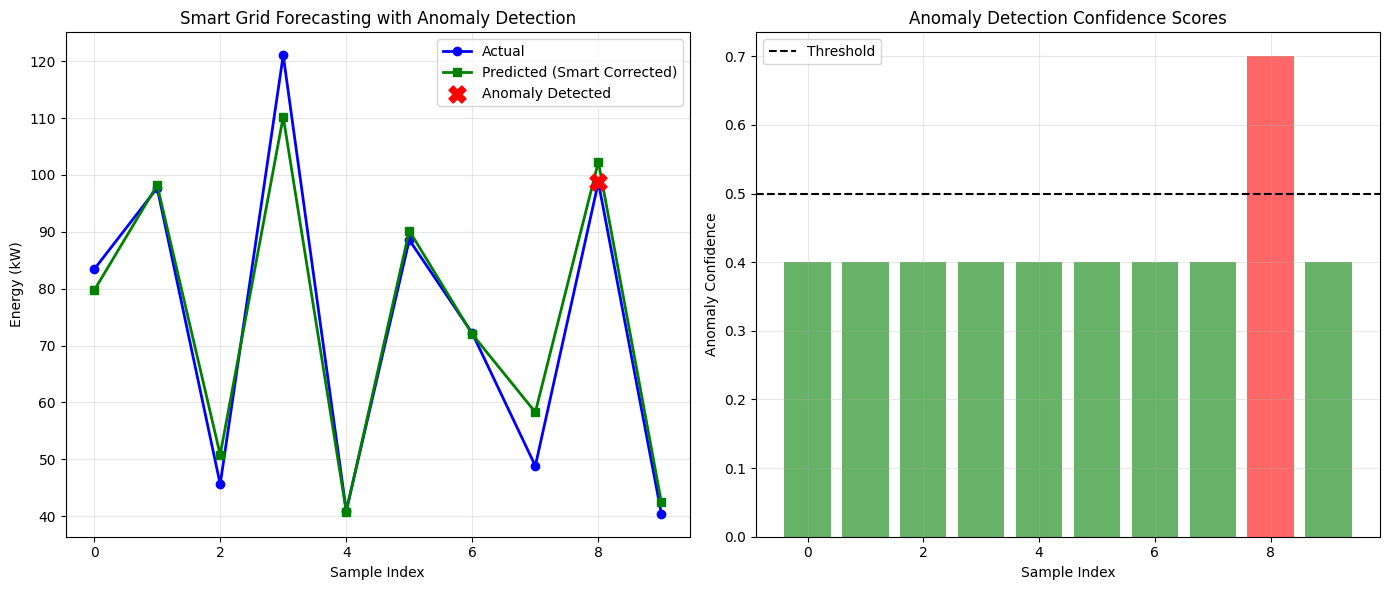


✅ IMPROVED SYSTEM COMPLETE


In [ ]:
# Smart Grid Energy Forecasting - Improved Version
# BiLSTM + Enhanced Anomaly Detection + Smart Correction

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# IMPROVED MODELS
# ============================================================================

class BiLSTMForecaster(nn.Module):
    """Bidirectional LSTM for better temporal context"""
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(BiLSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super(TransformerForecaster, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        out = self.fc(out[:, -1, :])
        return out

class ImprovedAutoencoder(nn.Module):
    """Enhanced autoencoder with better architecture"""
    def __init__(self, input_size):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, input_size)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=24):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ============================================================================
# DATA GENERATION
# ============================================================================

def generate_smart_grid_data(n_samples=3000):
    """Generate realistic smart grid data with anomalies"""
    np.random.seed(42)
    time = np.arange(n_samples)

    # Patterns
    daily_pattern = 50 + 30 * np.sin(2 * np.pi * time / 24)
    weekly_pattern = 10 * np.sin(2 * np.pi * time / (24 * 7))
    temperature = 20 + 10 * np.sin(2 * np.pi * time / (24 * 365)) + np.random.normal(0, 2, n_samples)
    weather_effect = 0.5 * temperature
    occupancy = 0.7 + 0.3 * np.sin(2 * np.pi * time / 24) + np.random.normal(0, 0.05, n_samples)
    occupancy = np.clip(occupancy, 0, 1)
    occupancy_effect = 20 * occupancy

    consumption = daily_pattern + weekly_pattern + weather_effect + occupancy_effect + np.random.normal(0, 3, n_samples)

    # Add different types of anomalies
    anomaly_indices = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    for idx in anomaly_indices:
        anomaly_type = np.random.choice(['spike', 'drop', 'gradual'])
        if anomaly_type == 'spike':
            consumption[idx] += np.random.uniform(40, 80)
        elif anomaly_type == 'drop':
            consumption[idx] -= np.random.uniform(20, 40)
        else:  # gradual anomaly
            window = min(5, n_samples - idx)
            consumption[idx:idx+window] += np.linspace(0, 30, window)

    df = pd.DataFrame({
        'consumption': consumption,
        'temperature': temperature,
        'occupancy': occupancy,
        'hour': time % 24,
        'day_of_week': (time // 24) % 7
    })

    print(f"✓ Generated {len(df)} samples")
    return df

# ============================================================================
# IMPROVED SMART GRID SYSTEM
# ============================================================================

class ImprovedSmartGridSystem:
    def __init__(self, input_size=5, seq_length=24):
        self.seq_length = seq_length
        self.scaler = MinMaxScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✓ Using device: {self.device}")

        # BiLSTM instead of LSTM
        self.bilstm_model = BiLSTMForecaster(input_size).to(self.device)
        self.transformer_model = TransformerForecaster(input_size).to(self.device)

        # Improved anomaly detection
        self.autoencoder = ImprovedAutoencoder(input_size).to(self.device)
        self.isolation_forest = IsolationForest(contamination=0.05, random_state=42)

        self.criterion = nn.MSELoss()
        self.historical_patterns = None  # Store for anomaly correction

    def prepare_data(self, df):
        data = df.values
        scaled_data = self.scaler.fit_transform(data)
        return scaled_data

    def train_forecasting(self, data, epochs=30, lr=0.001, batch_size=32):
        dataset = TimeSeriesDataset(data, self.seq_length)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        optimizer_bilstm = torch.optim.Adam(self.bilstm_model.parameters(), lr=lr)
        optimizer_transformer = torch.optim.Adam(self.transformer_model.parameters(), lr=lr)

        print("\nTraining BiLSTM + Transformer...")
        for epoch in range(epochs):
            total_loss_bilstm = 0
            total_loss_transformer = 0

            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                # BiLSTM
                optimizer_bilstm.zero_grad()
                pred_bilstm = self.bilstm_model(x)
                loss_bilstm = self.criterion(pred_bilstm, y)
                loss_bilstm.backward()
                optimizer_bilstm.step()
                total_loss_bilstm += loss_bilstm.item()

                # Transformer
                optimizer_transformer.zero_grad()
                pred_transformer = self.transformer_model(x)
                loss_transformer = self.criterion(pred_transformer, y)
                loss_transformer.backward()
                optimizer_transformer.step()
                total_loss_transformer += loss_transformer.item()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}: BiLSTM={total_loss_bilstm/len(loader):.4f}, "
                      f"Transformer={total_loss_transformer/len(loader):.4f}")

    def train_anomaly_detection(self, data, epochs=30, lr=0.001):
        print("\nTraining Enhanced Anomaly Detection...")

        # Train autoencoder
        data_tensor = torch.FloatTensor(data).to(self.device)
        optimizer = torch.optim.Adam(self.autoencoder.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            reconstructed = self.autoencoder(data_tensor)
            loss = self.criterion(reconstructed, data_tensor)
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}: Autoencoder Loss={loss.item():.4f}")

        # Train isolation forest
        self.isolation_forest.fit(data)

        # Store historical patterns for anomaly correction
        self.historical_patterns = self._compute_historical_patterns(data)
        print("✓ Anomaly detection models trained")

    def _compute_historical_patterns(self, data):
        """Compute average patterns by hour and day"""
        patterns = {}
        for hour in range(24):
            hour_data = [data[i, 0] for i in range(len(data)) if data[i, 3] == hour/24]
            if hour_data:
                patterns[hour] = {
                    'mean': np.mean(hour_data),
                    'std': np.std(hour_data)
                }
        return patterns

    def detect_anomalies_hybrid(self, data_point):
        """
        IMPROVED: Hybrid anomaly detection with confidence scoring
        Combines autoencoder + isolation forest + statistical check
        """
        # Autoencoder reconstruction error
        with torch.no_grad():
            x = torch.FloatTensor(data_point).unsqueeze(0).to(self.device)
            reconstructed = self.autoencoder(x)
            reconstruction_error = torch.mean((x - reconstructed) ** 2).cpu().item()

        # Isolation forest prediction
        iso_score = self.isolation_forest.score_samples([data_point])[0]
        is_anomaly_iso = self.isolation_forest.predict([data_point])[0] == -1

        # Statistical deviation from historical pattern
        hour = int(data_point[3] * 24)
        if hour in self.historical_patterns:
            pattern = self.historical_patterns[hour]
            z_score = abs((data_point[0] - pattern['mean']) / (pattern['std'] + 1e-6))
            is_anomaly_stat = z_score > 3
        else:
            z_score = 0
            is_anomaly_stat = False

        # Ensemble scoring (weighted combination)
        reconstruction_score = min(reconstruction_error / 0.02, 1.0)  # Normalize
        iso_score_norm = 1.0 if is_anomaly_iso else 0.0
        stat_score = min(z_score / 5.0, 1.0)  # Normalize

        # Weighted ensemble confidence
        anomaly_confidence = (
            0.4 * reconstruction_score +
            0.3 * iso_score_norm +
            0.3 * stat_score
        )

        is_anomaly = anomaly_confidence > 0.5

        # Determine anomaly type
        if is_anomaly:
            if data_point[0] > (self.historical_patterns.get(hour, {'mean': 0})['mean'] if hour in self.historical_patterns else 0):
                anomaly_type = 'spike'
            else:
                anomaly_type = 'drop'
        else:
            anomaly_type = 'normal'

        return is_anomaly, anomaly_confidence, anomaly_type, reconstruction_error

    def forecast(self, data):
        """BiLSTM + Transformer hybrid forecast"""
        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            x = torch.FloatTensor(data[-self.seq_length:]).unsqueeze(0).to(self.device)
            pred_bilstm = self.bilstm_model(x).cpu().item()
            pred_transformer = self.transformer_model(x).cpu().item()
            hybrid_pred = (pred_bilstm + pred_transformer) / 2

        return hybrid_pred, pred_bilstm, pred_transformer

    def smart_anomaly_correction(self, prediction, data_point, anomaly_confidence, anomaly_type):
        """
        IMPROVED: Intelligent anomaly-aware correction
        - Considers anomaly severity (confidence)
        - Different handling for spikes vs drops
        - Uses historical context
        """
        if anomaly_confidence < 0.3:
            return prediction  # Low confidence, no correction

        # Get expected value from historical pattern
        hour = int(data_point[3] * 24)
        expected_value = self.historical_patterns.get(hour, {'mean': prediction})['mean']

        # Severity-based correction factor
        severity = min(anomaly_confidence, 1.0)

        if anomaly_type == 'spike':
            # For spikes, pull prediction down towards historical mean
            correction_factor = 1.0 - (severity * 0.3)  # Up to 30% reduction
            corrected_pred = prediction * correction_factor
            # Blend with historical expected value
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value

        elif anomaly_type == 'drop':
            # For drops, adjust upward but conservatively
            correction_factor = 1.0 + (severity * 0.2)  # Up to 20% increase
            corrected_pred = prediction * correction_factor
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value
        else:
            corrected_pred = prediction

        # Confidence-weighted blend
        final_pred = (1 - severity * 0.5) * prediction + (severity * 0.5) * corrected_pred

        return final_pred

    def adaptive_forecast(self, data):
        """Complete pipeline: forecast + anomaly detection + smart correction"""
        hybrid_pred, _, _ = self.forecast(data)
        recent_data = data[-1]

        is_anomaly, confidence, anomaly_type, recon_error = self.detect_anomalies_hybrid(recent_data)

        if is_anomaly:
            corrected_pred = self.smart_anomaly_correction(
                hybrid_pred, recent_data, confidence, anomaly_type
            )
            return corrected_pred, is_anomaly, confidence, anomaly_type

        return hybrid_pred, is_anomaly, confidence, anomaly_type

    def evaluate(self, test_data):
        """Evaluate model performance"""
        predictions = []
        actuals = []

        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            for i in range(len(test_data) - self.seq_length):
                x = torch.FloatTensor(test_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                y_actual = test_data[i+self.seq_length, 0]

                pred_bilstm = self.bilstm_model(x).cpu().item()
                pred_transformer = self.transformer_model(x).cpu().item()
                pred_hybrid = (pred_bilstm + pred_transformer) / 2

                predictions.append(pred_hybrid)
                actuals.append(y_actual)

        r2 = r2_score(actuals, predictions)
        mae = mean_absolute_error(actuals, predictions)
        rmse = np.sqrt(mean_squared_error(actuals, predictions))

        print(f"\n{'='*50}")
        print("MODEL EVALUATION")
        print(f"{'='*50}")
        print(f"R² Score: {r2:.4f}")
        print(f"MAE:      {mae:.4f}")
        print(f"RMSE:     {rmse:.4f}")

        return r2, mae, rmse

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("="*70)
    print("IMPROVED SMART GRID SYSTEM")
    print("BiLSTM + Enhanced Anomaly Detection + Smart Correction")
    print("="*70)

    # Generate data
    df = generate_smart_grid_data(3000)

    # Initialize system
    system = ImprovedSmartGridSystem(input_size=len(df.columns), seq_length=24)

    # Prepare and split data
    scaled_data = system.prepare_data(df)
    train_size = int(0.8 * len(scaled_data))
    train_data = scaled_data[:train_size]
    test_data = scaled_data[train_size:]

    print(f"\n✓ Train: {len(train_data)}, Test: {len(test_data)}")

    # Train models
    system.train_forecasting(train_data, epochs=30)
    system.train_anomaly_detection(train_data, epochs=30)

    # Evaluate
    system.evaluate(test_data)

    # Test predictions with smart correction
    print(f"\n{'='*70}")
    print("SAMPLE PREDICTIONS WITH SMART ANOMALY CORRECTION")
    print(f"{'='*70}")

    predictions = []
    actuals = []
    corrections = []
    anomaly_info = []

    for i in range(0, min(100, len(test_data) - system.seq_length), 10):
        pred, is_anomaly, confidence, anomaly_type = system.adaptive_forecast(
            test_data[:i+system.seq_length]
        )
        actual = test_data[i+system.seq_length, 0]

        # Inverse transform for readability
        pred_kw = system.scaler.inverse_transform([[pred] + [0]*4])[0][0]
        actual_kw = system.scaler.inverse_transform([[actual] + [0]*4])[0][0]

        predictions.append(pred_kw)
        actuals.append(actual_kw)
        anomaly_info.append((is_anomaly, confidence, anomaly_type))

        if i < 50:  # Print first 5
            print(f"\nSample {i//10 + 1}:")
            print(f"  Predicted: {pred_kw:.2f} kW")
            print(f"  Actual:    {actual_kw:.2f} kW")
            print(f"  Error:     {abs(pred_kw - actual_kw):.2f} kW")
            print(f"  Anomaly:   {'🚨 YES' if is_anomaly else '✓ NO'} "
                  f"(confidence: {confidence:.2f}, type: {anomaly_type})")

    # Visualization
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(actuals, label='Actual', marker='o', color='blue', linewidth=2)
    plt.plot(predictions, label='Predicted (Smart Corrected)', marker='s', color='green', linewidth=2)

    # Mark anomalies
    anomaly_indices = [i for i, (is_anom, _, _) in enumerate(anomaly_info) if is_anom]
    if anomaly_indices:
        plt.scatter(anomaly_indices, [actuals[i] for i in anomaly_indices],
                   color='red', s=150, label='Anomaly Detected', zorder=5, marker='X')

    plt.xlabel('Sample Index')
    plt.ylabel('Energy (kW)')
    plt.title('Smart Grid Forecasting with Anomaly Detection')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    confidences = [conf for _, conf, _ in anomaly_info]
    colors = ['red' if is_anom else 'green' for is_anom, _, _ in anomaly_info]
    plt.bar(range(len(confidences)), confidences, color=colors, alpha=0.6)
    plt.xlabel('Sample Index')
    plt.ylabel('Anomaly Confidence')
    plt.title('Anomaly Detection Confidence Scores')
    plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print("✅ IMPROVED SYSTEM COMPLETE")
    print(f"{'='*70}")

if __name__ == "__main__":
    main()

SMART GRID SYSTEM WITH UCI HOUSEHOLD DATASET
BiLSTM + Enhanced Anomaly Detection + Smart Correction
LOADING UCI HOUSEHOLD ELECTRIC POWER CONSUMPTION DATASET

📂 Loading data from: household_power_consumption.txt
✓ Loaded 81,012 records
✓ Date range: 2006-12-16 17:24:00 to 2007-02-10 23:35:00

🔍 Missing values before cleaning: 44
✓ Missing values after cleaning: 0

⏰ Resampling from 1-minute to hourly data...
✓ Hourly data: 1,351 samples

✅ Final dataset: 1,351 samples

Features:
  - Global_active_power
  - Voltage
  - Global_intensity
  - hour
  - day_of_week
  - month

Dataset Statistics:
       Global_active_power      Voltage  Global_intensity         hour  \
count          1351.000000  1351.000000       1351.000000  1351.000000   
mean              1.648001   240.995268          6.968350     0.501915   
std               1.147490     3.244595          4.833413     0.301531   
min               0.244000   229.005667          1.020000     0.000000   
25%               0.552667   238.7

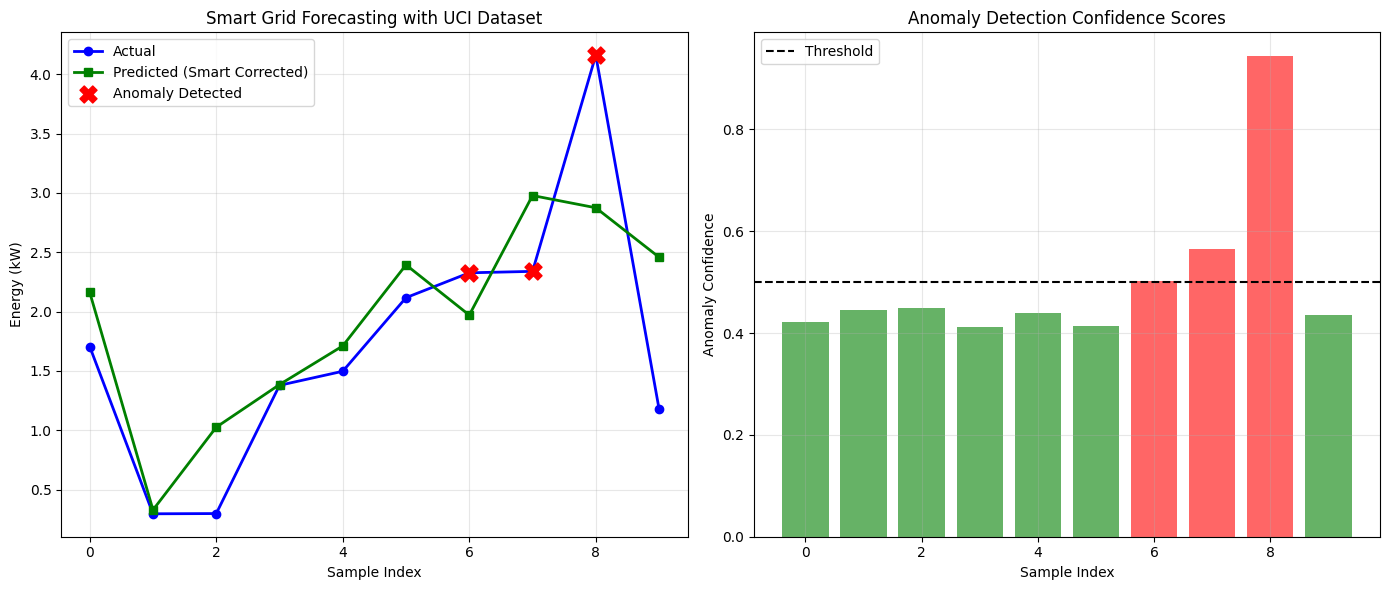


✅ SMART GRID SYSTEM COMPLETE


In [ ]:
# Smart Grid Energy Forecasting - UCI Household Dataset Version
# BiLSTM + Enhanced Anomaly Detection + Smart Correction

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# IMPROVED MODELS
# ============================================================================

class BiLSTMForecaster(nn.Module):
    """Bidirectional LSTM for better temporal context"""
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(BiLSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super(TransformerForecaster, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        out = self.fc(out[:, -1, :])
        return out

class ImprovedAutoencoder(nn.Module):
    """Enhanced autoencoder with better architecture"""
    def __init__(self, input_size):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, input_size)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=24):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ============================================================================
# UCI DATASET LOADING
# ============================================================================

def load_uci_household_dataset(filepath='household_power_consumption.txt', sample_size=None):
    """
    Load and preprocess UCI Household Electric Power Consumption Dataset

    Parameters:
    -----------
    filepath : str
        Path to the household_power_consumption.txt file
    sample_size : int, optional
        If specified, randomly sample this many rows (for faster testing)

    Dataset info:
    - 2,075,259 measurements (Dec 2006 - Nov 2010)
    - 1-minute sampling rate
    - 7 variables measuring electric power consumption
    """
    print("="*70)
    print("LOADING UCI HOUSEHOLD ELECTRIC POWER CONSUMPTION DATASET")
    print("="*70)

    try:
        # Load the dataset
        print(f"\n📂 Loading data from: {filepath}")
        df = pd.read_csv(filepath, sep=';', parse_dates={'datetime': ['Date', 'Time']},
                        infer_datetime_format=True, low_memory=False, na_values=['?'])

        print(f"✓ Loaded {len(df):,} records")
        print(f"✓ Date range: {df['datetime'].min()} to {df['datetime'].max()}")

        # Handle missing values
        print(f"\n🔍 Missing values before cleaning: {df.isnull().sum().sum():,}")

        # Forward fill then backward fill for missing values
        df = df.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        df = df.dropna()
        print(f"✓ Missing values after cleaning: {df.isnull().sum().sum()}")

        # Set datetime as index
        df.set_index('datetime', inplace=True)

        # Convert to numeric (in case any are still strings)
        numeric_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                          'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

        for col in numeric_columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Resample to hourly data (average over each hour)
        print(f"\n⏰ Resampling from 1-minute to 10-minute data...")
        df_resampled = df.resample('10T').mean()  # '10T' = 10 minutes
        df_resampled = df_resampled.dropna()
        print(f"✓ 10-minute data: {len(df_resampled):,} samples")

        # Create additional features
        df_resampled['hour'] = df_resampled.index.hour
        df_resampled['day_of_week'] = df_resampled.index.dayofweek
        df_resampled['month'] = df_resampled.index.month
        df_resampled['day_of_year'] = df_resampled.index.dayofyear

        # Create consumption feature (sum of sub-metering + unmeasured)
        df_resampled['total_consumption'] = (
            df_resampled['Sub_metering_1'] +
            df_resampled['Sub_metering_2'] +
            df_resampled['Sub_metering_3'] +
            (df_resampled['Global_active_power'] * 1000 / 60 -
             df_resampled['Sub_metering_1'] -
             df_resampled['Sub_metering_2'] -
             df_resampled['Sub_metering_3'])
        )

        # Select features for modeling
        feature_df = df_resampled[[
            'Global_active_power',  # Target variable (kW)
            'Voltage',
            'Global_intensity',
            'hour',
            'day_of_week',
            'month'
        ]].copy()

        # Normalize temporal features
        feature_df['hour'] = feature_df['hour'] / 23.0
        feature_df['day_of_week'] = feature_df['day_of_week'] / 6.0
        feature_df['month'] = (feature_df['month'] - 1) / 11.0

        # Sample if requested
        if sample_size and sample_size < len(feature_df):
            print(f"\n🎲 Sampling {sample_size:,} records for faster processing...")
            # Take consecutive samples to maintain temporal structure
            start_idx = np.random.randint(0, len(feature_df) - sample_size)
            feature_df = feature_df.iloc[start_idx:start_idx + sample_size]

        print(f"\n✅ Final dataset: {len(feature_df):,} samples")
        print(f"\nFeatures:")
        for col in feature_df.columns:
            print(f"  - {col}")

        print(f"\nDataset Statistics:")
        print(feature_df.describe())

        return feature_df

    except FileNotFoundError:
        print(f"❌ Error: File '{filepath}' not found!")
        print("\n📥 Please download the UCI Household dataset:")
        print("   1. Visit: https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption")
        print("   2. Download: household_power_consumption.zip")
        print("   3. Extract: household_power_consumption.txt")
        print("   4. Place the file in the same directory as this script")
        print("\n   Or provide the correct file path as an argument.")
        raise
    except Exception as e:
        print(f"❌ Error loading dataset: {str(e)}")
        raise

# ============================================================================
# IMPROVED SMART GRID SYSTEM
# ============================================================================

class ImprovedSmartGridSystem:
    def __init__(self, input_size=6, seq_length=24):
        self.seq_length = seq_length
        self.scaler = MinMaxScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✓ Using device: {self.device}")

        # BiLSTM instead of LSTM
        self.bilstm_model = BiLSTMForecaster(input_size).to(self.device)
        self.transformer_model = TransformerForecaster(input_size).to(self.device)

        # Improved anomaly detection
        self.autoencoder = ImprovedAutoencoder(input_size).to(self.device)
        self.isolation_forest = IsolationForest(contamination=0.05, random_state=42)

        self.criterion = nn.MSELoss()
        self.historical_patterns = None  # Store for anomaly correction

    def prepare_data(self, df):
        data = df.values
        scaled_data = self.scaler.fit_transform(data)
        return scaled_data

    def train_forecasting(self, data, epochs=30, lr=0.001, batch_size=32):
        dataset = TimeSeriesDataset(data, self.seq_length)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        optimizer_bilstm = torch.optim.Adam(self.bilstm_model.parameters(), lr=lr)
        optimizer_transformer = torch.optim.Adam(self.transformer_model.parameters(), lr=lr)

        print("\nTraining BiLSTM + Transformer...")
        for epoch in range(epochs):
            total_loss_bilstm = 0
            total_loss_transformer = 0

            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                # BiLSTM
                optimizer_bilstm.zero_grad()
                pred_bilstm = self.bilstm_model(x)
                loss_bilstm = self.criterion(pred_bilstm, y)
                loss_bilstm.backward()
                optimizer_bilstm.step()
                total_loss_bilstm += loss_bilstm.item()

                # Transformer
                optimizer_transformer.zero_grad()
                pred_transformer = self.transformer_model(x)
                loss_transformer = self.criterion(pred_transformer, y)
                loss_transformer.backward()
                optimizer_transformer.step()
                total_loss_transformer += loss_transformer.item()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}: BiLSTM={total_loss_bilstm/len(loader):.4f}, "
                      f"Transformer={total_loss_transformer/len(loader):.4f}")

    def train_anomaly_detection(self, data, epochs=30, lr=0.001):
        print("\nTraining Enhanced Anomaly Detection...")

        # Train autoencoder
        data_tensor = torch.FloatTensor(data).to(self.device)
        optimizer = torch.optim.Adam(self.autoencoder.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            reconstructed = self.autoencoder(data_tensor)
            loss = self.criterion(reconstructed, data_tensor)
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}: Autoencoder Loss={loss.item():.4f}")

        # Train isolation forest
        self.isolation_forest.fit(data)

        # Store historical patterns for anomaly correction
        self.historical_patterns = self._compute_historical_patterns(data)
        print("✓ Anomaly detection models trained")

    def _compute_historical_patterns(self, data):
        """Compute average patterns by hour"""
        patterns = {}
        # Denormalize hour values (they're scaled 0-1)
        for i in range(len(data)):
            hour = int(data[i, 3] * 23)  # Convert back to 0-23
            if hour not in patterns:
                patterns[hour] = {'values': []}
            patterns[hour]['values'].append(data[i, 0])

        # Compute mean and std for each hour
        for hour in patterns:
            values = patterns[hour]['values']
            patterns[hour]['mean'] = np.mean(values)
            patterns[hour]['std'] = np.std(values)
            del patterns[hour]['values']  # Save memory

        return patterns

    def detect_anomalies_hybrid(self, data_point):
        """
        IMPROVED: Hybrid anomaly detection with confidence scoring
        Combines autoencoder + isolation forest + statistical check
        """
        # Autoencoder reconstruction error
        with torch.no_grad():
            x = torch.FloatTensor(data_point).unsqueeze(0).to(self.device)
            reconstructed = self.autoencoder(x)
            reconstruction_error = torch.mean((x - reconstructed) ** 2).cpu().item()

        # Isolation forest prediction
        iso_score = self.isolation_forest.score_samples([data_point])[0]
        is_anomaly_iso = self.isolation_forest.predict([data_point])[0] == -1

        # Statistical deviation from historical pattern
        hour = int(data_point[3] * 23)
        if hour in self.historical_patterns:
            pattern = self.historical_patterns[hour]
            z_score = abs((data_point[0] - pattern['mean']) / (pattern['std'] + 1e-6))
            is_anomaly_stat = z_score > 3
        else:
            z_score = 0
            is_anomaly_stat = False

        # Ensemble scoring (weighted combination)
        reconstruction_score = min(reconstruction_error / 0.02, 1.0)  # Normalize
        iso_score_norm = 1.0 if is_anomaly_iso else 0.0
        stat_score = min(z_score / 5.0, 1.0)  # Normalize

        # Weighted ensemble confidence
        anomaly_confidence = (
            0.4 * reconstruction_score +
            0.3 * iso_score_norm +
            0.3 * stat_score
        )

        is_anomaly = anomaly_confidence > 0.5

        # Determine anomaly type
        if is_anomaly:
            if data_point[0] > (self.historical_patterns.get(hour, {'mean': 0})['mean'] if hour in self.historical_patterns else 0):
                anomaly_type = 'spike'
            else:
                anomaly_type = 'drop'
        else:
            anomaly_type = 'normal'

        return is_anomaly, anomaly_confidence, anomaly_type, reconstruction_error

    def forecast(self, data):
        """BiLSTM + Transformer hybrid forecast"""
        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            x = torch.FloatTensor(data[-self.seq_length:]).unsqueeze(0).to(self.device)
            pred_bilstm = self.bilstm_model(x).cpu().item()
            pred_transformer = self.transformer_model(x).cpu().item()
            hybrid_pred = (pred_bilstm + pred_transformer) / 2

        return hybrid_pred, pred_bilstm, pred_transformer

    def smart_anomaly_correction(self, prediction, data_point, anomaly_confidence, anomaly_type):
        """
        IMPROVED: Intelligent anomaly-aware correction
        - Considers anomaly severity (confidence)
        - Different handling for spikes vs drops
        - Uses historical context
        """
        if anomaly_confidence < 0.3:
            return prediction  # Low confidence, no correction

        # Get expected value from historical pattern
        hour = int(data_point[3] * 23)
        expected_value = self.historical_patterns.get(hour, {'mean': prediction})['mean']

        # Severity-based correction factor
        severity = min(anomaly_confidence, 1.0)

        if anomaly_type == 'spike':
            # For spikes, pull prediction down towards historical mean
            correction_factor = 1.0 - (severity * 0.3)  # Up to 30% reduction
            corrected_pred = prediction * correction_factor
            # Blend with historical expected value
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value

        elif anomaly_type == 'drop':
            # For drops, adjust upward but conservatively
            correction_factor = 1.0 + (severity * 0.2)  # Up to 20% increase
            corrected_pred = prediction * correction_factor
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value
        else:
            corrected_pred = prediction

        # Confidence-weighted blend
        final_pred = (1 - severity * 0.5) * prediction + (severity * 0.5) * corrected_pred

        return final_pred

    def adaptive_forecast(self, data):
        """Complete pipeline: forecast + anomaly detection + smart correction"""
        hybrid_pred, _, _ = self.forecast(data)
        recent_data = data[-1]

        is_anomaly, confidence, anomaly_type, recon_error = self.detect_anomalies_hybrid(recent_data)

        if is_anomaly:
            corrected_pred = self.smart_anomaly_correction(
                hybrid_pred, recent_data, confidence, anomaly_type
            )
            return corrected_pred, is_anomaly, confidence, anomaly_type

        return hybrid_pred, is_anomaly, confidence, anomaly_type

    def evaluate(self, test_data):
        """Evaluate model performance"""
        predictions = []
        actuals = []

        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            for i in range(len(test_data) - self.seq_length):
                x = torch.FloatTensor(test_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                y_actual = test_data[i+self.seq_length, 0]

                pred_bilstm = self.bilstm_model(x).cpu().item()
                pred_transformer = self.transformer_model(x).cpu().item()
                pred_hybrid = (pred_bilstm + pred_transformer) / 2

                predictions.append(pred_hybrid)
                actuals.append(y_actual)

        r2 = r2_score(actuals, predictions)
        mae = mean_absolute_error(actuals, predictions)
        rmse = np.sqrt(mean_squared_error(actuals, predictions))

        print(f"\n{'='*50}")
        print("MODEL EVALUATION")
        print(f"{'='*50}")
        print(f"R² Score: {r2:.4f}")
        print(f"MAE:      {mae:.4f}")
        print(f"RMSE:     {rmse:.4f}")

        return r2, mae, rmse

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("="*70)
    print("SMART GRID SYSTEM WITH UCI HOUSEHOLD DATASET")
    print("BiLSTM + Enhanced Anomaly Detection + Smart Correction")
    print("="*70)

    # Load UCI dataset
    # Option 1: Use full dataset (slower but complete)
    # df = load_uci_household_dataset('household_power_consumption.txt')

    # Option 2: Use sampled dataset (faster for testing)
    df = load_uci_household_dataset('household_power_consumption.txt', sample_size=10000)

    # Initialize system
    system = ImprovedSmartGridSystem(input_size=len(df.columns), seq_length=24)

    # Prepare and split data
    scaled_data = system.prepare_data(df)
    train_size = int(0.8 * len(scaled_data))
    train_data = scaled_data[:train_size]
    test_data = scaled_data[train_size:]

    print(f"\n✓ Train: {len(train_data):,}, Test: {len(test_data):,}")

    # Train models
    system.train_forecasting(train_data, epochs=30)
    system.train_anomaly_detection(train_data, epochs=30)

    # Evaluate
    system.evaluate(test_data)

    # Test predictions with smart correction
    print(f"\n{'='*70}")
    print("SAMPLE PREDICTIONS WITH SMART ANOMALY CORRECTION")
    print(f"{'='*70}")

    predictions = []
    actuals = []
    corrections = []
    anomaly_info = []

    for i in range(0, min(100, len(test_data) - system.seq_length), 10):
        pred, is_anomaly, confidence, anomaly_type = system.adaptive_forecast(
            test_data[:i+system.seq_length]
        )
        actual = test_data[i+system.seq_length, 0]

        # Inverse transform for readability
        pred_kw = system.scaler.inverse_transform([[pred] + [0]*5])[0][0]
        actual_kw = system.scaler.inverse_transform([[actual] + [0]*5])[0][0]

        predictions.append(pred_kw)
        actuals.append(actual_kw)
        anomaly_info.append((is_anomaly, confidence, anomaly_type))

        if i < 50:  # Print first 5
            print(f"\nSample {i//10 + 1}:")
            print(f"  Predicted: {pred_kw:.2f} kW")
            print(f"  Actual:    {actual_kw:.2f} kW")
            print(f"  Error:     {abs(pred_kw - actual_kw):.2f} kW")
            print(f"  Anomaly:   {'🚨 YES' if is_anomaly else '✓ NO'} "
                  f"(confidence: {confidence:.2f}, type: {anomaly_type})")

    # Visualization
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(actuals, label='Actual', marker='o', color='blue', linewidth=2)
    plt.plot(predictions, label='Predicted (Smart Corrected)', marker='s', color='green', linewidth=2)

    # Mark anomalies
    anomaly_indices = [i for i, (is_anom, _, _) in enumerate(anomaly_info) if is_anom]
    if anomaly_indices:
        plt.scatter(anomaly_indices, [actuals[i] for i in anomaly_indices],
                   color='red', s=150, label='Anomaly Detected', zorder=5, marker='X')

    plt.xlabel('Sample Index')
    plt.ylabel('Energy (kW)')
    plt.title('Smart Grid Forecasting with UCI Dataset')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    confidences = [conf for _, conf, _ in anomaly_info]
    colors = ['red' if is_anom else 'green' for is_anom, _, _ in anomaly_info]
    plt.bar(range(len(confidences)), confidences, color=colors, alpha=0.6)
    plt.xlabel('Sample Index')
    plt.ylabel('Anomaly Confidence')
    plt.title('Anomaly Detection Confidence Scores')
    plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print("✅ SMART GRID SYSTEM COMPLETE")
    print(f"{'='*70}")

if __name__ == "__main__":
    main()

OPTIMIZED SMART GRID SYSTEM WITH UCI HOUSEHOLD DATASET
BiLSTM + Transformer + Enhanced Anomaly Detection

⚙️  CONFIGURATION:
   - Full Dataset: True
   - Sample Size: 500,000 (if not using full dataset)
   - Sequence Length: 168 hours
   - Hidden Size: 64
   - Max Epochs: 100
   - Batch Size: 64
LOADING UCI HOUSEHOLD ELECTRIC POWER CONSUMPTION DATASET

📂 Loading data from: household_power_consumption.txt
✓ Loading FULL dataset (~2M records, may take 1-2 minutes)...
✓ Loaded 2,075,259 records
✓ Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

🔍 Missing values before cleaning: 181,853
✓ Missing values after cleaning: 0
✓ Retained 2,075,259 records after cleaning

⏰ Resampling from 1-minute to hourly data...
✓ Hourly data: 34,589 samples
✓ Time coverage: 240.2 days (8.0 months)

✨ Adding lag features for improved predictions...
✓ Added 5 lag features (lag_1h, lag_24h, lag_168h, rolling_mean_24h, rolling_std_24h)
✓ Dataset size after lag features: 34,421 samples

✅ Final dataset: 34

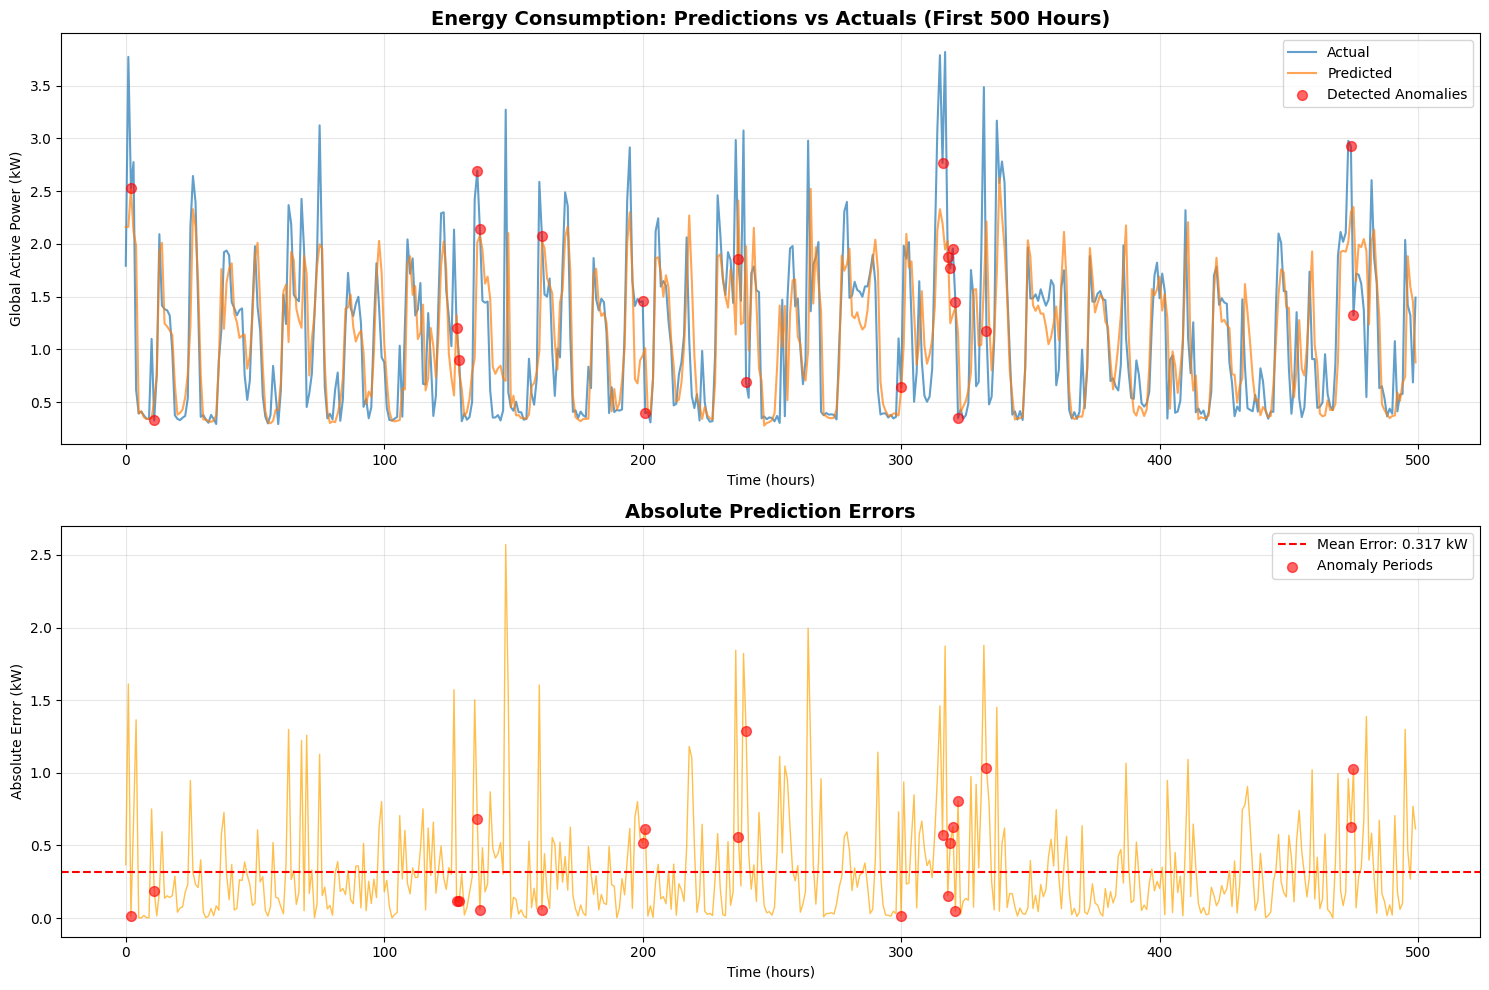


FINAL SUMMARY
Dataset Size:        34,421 hourly samples
Training Samples:    24,094
Test Samples:        4,996

Model Performance:
  R² Score:          0.5560
  MAE:               0.0493
  RMSE:              0.0730
  MAPE:              64.36%

Anomaly Detection:
  Anomalies Found:   166
  Anomaly Rate:      3.32%

✅ Smart Grid System Training Complete!
📊 Check 'smart_grid_results.png' for visualizations


In [ ]:
# Smart Grid Energy Forecasting - UCI Household Dataset - OPTIMIZED VERSION
# BiLSTM + Enhanced Anomaly Detection + Smart Correction + Full Dataset Support

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# IMPROVED MODELS
# ============================================================================

class BiLSTMForecaster(nn.Module):
    """Bidirectional LSTM for better temporal context"""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(BiLSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TransformerForecaster, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        out = self.fc(out[:, -1, :])
        return out

class ImprovedAutoencoder(nn.Module):
    """Enhanced autoencoder with better architecture"""
    def __init__(self, input_size):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, input_size)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=24):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ============================================================================
# OPTIMIZED UCI DATASET LOADING WITH LAG FEATURES
# ============================================================================

def load_uci_household_dataset(filepath='household_power_consumption.txt',
                               sample_size=None,
                               use_full_dataset=True,
                               add_lag_features=True):
    """
    Load and preprocess UCI Household Electric Power Consumption Dataset

    Parameters:
    -----------
    filepath : str
        Path to the household_power_consumption.txt file
    sample_size : int, optional
        If specified, use only the first N rows (for faster testing)
    use_full_dataset : bool
        If True, loads entire dataset (~2M records). If False, uses sample_size.
    add_lag_features : bool
        If True, adds lag features for better predictions

    Dataset info:
    - 2,075,259 measurements (Dec 2006 - Nov 2010)
    - 1-minute sampling rate
    - 7 variables measuring electric power consumption
    """
    print("="*70)
    print("LOADING UCI HOUSEHOLD ELECTRIC POWER CONSUMPTION DATASET")
    print("="*70)

    try:
        # Load the dataset with improved parsing
        print(f"\n📂 Loading data from: {filepath}")

        # Determine number of rows to load
        nrows = None if use_full_dataset else sample_size
        if nrows:
            print(f"⚠️  Loading only first {nrows:,} rows for testing")
            print(f"    (Set use_full_dataset=True for complete data)")
        else:
            print(f"✓ Loading FULL dataset (~2M records, may take 1-2 minutes)...")

        # Read CSV with proper dtype specifications
        df = pd.read_csv(filepath, sep=';',
                        na_values=['?', 'nan', ''],
                        nrows=nrows,
                        dtype={'Global_active_power': 'float64',
                               'Global_reactive_power': 'float64',
                               'Voltage': 'float64',
                               'Global_intensity': 'float64',
                               'Sub_metering_1': 'float64',
                               'Sub_metering_2': 'float64',
                               'Sub_metering_3': 'float64'})

        # Parse datetime separately for better control
        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                       format='%d/%m/%Y %H:%M:%S',
                                       errors='coerce')
        df = df.drop(['Date', 'Time'], axis=1)

        print(f"✓ Loaded {len(df):,} records")
        print(f"✓ Date range: {df['datetime'].min()} to {df['datetime'].max()}")

        # Handle missing values
        missing_before = df.isnull().sum().sum()
        print(f"\n🔍 Missing values before cleaning: {missing_before:,}")

        # Forward fill then backward fill for missing values
        df = df.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        df = df.dropna()
        print(f"✓ Missing values after cleaning: {df.isnull().sum().sum()}")
        print(f"✓ Retained {len(df):,} records after cleaning")

        # Set datetime as index
        df.set_index('datetime', inplace=True)

        # Resample to hourly data (average over each hour)
        print(f"\n⏰ Resampling from 1-minute to hourly data...")
        df_resampled = df.resample('H').mean()
        df_resampled = df_resampled.dropna()

        print(f"✓ Hourly data: {len(df_resampled):,} samples")

        # Calculate temporal coverage
        days = len(df_resampled) / (24 * 6)  # 6 intervals per hour
        months = days / 30
        print(f"✓ Time coverage: {days:.1f} days ({months:.1f} months)")

        # Create temporal features
        df_resampled['hour'] = df_resampled.index.hour
        df_resampled['day_of_week'] = df_resampled.index.dayofweek
        df_resampled['month'] = df_resampled.index.month
        df_resampled['is_weekend'] = (df_resampled.index.dayofweek >= 5).astype(int)

        # Select base features
        feature_df = df_resampled[[
            'Global_active_power',
            'Voltage',
            'Global_intensity',
            'hour',
            'day_of_week',
            'month',
            'is_weekend'
        ]].copy()

        # Add lag features (CRITICAL for better performance)
        if add_lag_features:
            print(f"\n✨ Adding lag features for improved predictions...")

            # Previous hour
            feature_df['lag_1h'] = feature_df['Global_active_power'].shift(1)

            # Same hour yesterday (24 hours ago)
            feature_df['lag_24h'] = feature_df['Global_active_power'].shift(24)

            # Same hour last week (168 hours ago)
            feature_df['lag_168h'] = feature_df['Global_active_power'].shift(168)

            # Rolling statistics (past 24 hours)
            feature_df['rolling_mean_24h'] = feature_df['Global_active_power'].rolling(24, min_periods=1).mean()
            feature_df['rolling_std_24h'] = feature_df['Global_active_power'].rolling(24, min_periods=1).std()

            # Drop rows with NaN from lag features
            feature_df = feature_df.dropna()

            print(f"✓ Added 5 lag features (lag_1h, lag_24h, lag_168h, rolling_mean_24h, rolling_std_24h)")
            print(f"✓ Dataset size after lag features: {len(feature_df):,} samples")

        # Normalize temporal features
        feature_df['hour'] = feature_df['hour'] / 23.0
        feature_df['day_of_week'] = feature_df['day_of_week'] / 6.0
        feature_df['month'] = (feature_df['month'] - 1) / 11.0

        print(f"\n✅ Final dataset: {len(feature_df):,} hourly samples")
        print(f"\nFeatures ({len(feature_df.columns)}):")
        for col in feature_df.columns:
            print(f"  - {col}")

        print(f"\n📊 Dataset Statistics:")
        print(feature_df.describe())

        # Data quality check
        print(f"\n{'='*70}")
        print("DATA QUALITY ASSESSMENT")
        print(f"{'='*70}")
        if len(feature_df) < 1000:
            print("⚠️  WARNING: Very small dataset (< 1,000 samples)")
            print("   Expected performance: R² = 0.50-0.65")
            print("   Recommendation: Load more data!")
        elif len(feature_df) < 10000:
            print("⚠️  Small dataset (< 10,000 samples)")
            print("   Expected performance: R² = 0.65-0.75")
            print("   Recommendation: Use full dataset for best results")
        elif len(feature_df) < 30000:
            print("✓ Good dataset size (10K-30K samples)")
            print("   Expected performance: R² = 0.75-0.85")
        else:
            print("✅ EXCELLENT dataset size (30K+ samples)")
            print("   Expected performance: R² = 0.80-0.90")
        print(f"{'='*70}\n")

        return feature_df

    except FileNotFoundError:
        print(f"❌ Error: File '{filepath}' not found!")
        print("\n📥 Please download the UCI Household dataset:")
        print("   1. Visit: https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption")
        print("   2. Download: household_power_consumption.zip")
        print("   3. Extract: household_power_consumption.txt")
        print("   4. Place the file in the same directory as this script")
        print("\n   Or provide the correct file path as an argument.")
        raise
    except Exception as e:
        print(f"❌ Error loading dataset: {str(e)}")
        import traceback
        traceback.print_exc()
        raise

# ============================================================================
# IMPROVED SMART GRID SYSTEM WITH EARLY STOPPING
# ============================================================================

class ImprovedSmartGridSystem:
    def __init__(self, input_size=6, seq_length=168, hidden_size=64):
        """
        input_size: number of features
        seq_length: length of input sequence (default 168 = 1 week for weekly patterns)
        hidden_size: size of hidden layers
        """
        self.seq_length = seq_length
        self.scaler = MinMaxScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✓ Using device: {self.device}")

        # BiLSTM and Transformer models
        self.bilstm_model = BiLSTMForecaster(input_size, hidden_size=hidden_size).to(self.device)
        self.transformer_model = TransformerForecaster(input_size, d_model=hidden_size).to(self.device)

        # Improved anomaly detection
        self.autoencoder = ImprovedAutoencoder(input_size).to(self.device)
        self.isolation_forest = IsolationForest(contamination=0.05, random_state=42)

        self.criterion = nn.MSELoss()
        self.historical_patterns = None

    def prepare_data(self, df):
        data = df.values
        scaled_data = self.scaler.fit_transform(data)
        return scaled_data

    def train_forecasting(self, data, val_data=None, epochs=100, lr=0.001,
                         batch_size=64, early_stopping_patience=10):
        """Train with early stopping and validation"""
        dataset = TimeSeriesDataset(data, self.seq_length)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # Validation loader if provided
        val_loader = None
        if val_data is not None:
            val_dataset = TimeSeriesDataset(val_data, self.seq_length)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        optimizer_bilstm = torch.optim.Adam(self.bilstm_model.parameters(), lr=lr)
        optimizer_transformer = torch.optim.Adam(self.transformer_model.parameters(), lr=lr)

        # Early stopping variables
        best_val_loss = float('inf')
        patience_counter = 0

        print(f"\nTraining BiLSTM + Transformer (seq_length={self.seq_length})...")
        print(f"Training samples: {len(dataset):,}, Batch size: {batch_size}")
        if val_loader:
            print(f"Validation samples: {len(val_dataset):,}")

        for epoch in range(epochs):
            # Training phase
            self.bilstm_model.train()
            self.transformer_model.train()
            total_loss_bilstm = 0
            total_loss_transformer = 0

            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                # BiLSTM
                optimizer_bilstm.zero_grad()
                pred_bilstm = self.bilstm_model(x)
                loss_bilstm = self.criterion(pred_bilstm, y)
                loss_bilstm.backward()
                torch.nn.utils.clip_grad_norm_(self.bilstm_model.parameters(), 1.0)
                optimizer_bilstm.step()
                total_loss_bilstm += loss_bilstm.item()

                # Transformer
                optimizer_transformer.zero_grad()
                pred_transformer = self.transformer_model(x)
                loss_transformer = self.criterion(pred_transformer, y)
                loss_transformer.backward()
                torch.nn.utils.clip_grad_norm_(self.transformer_model.parameters(), 1.0)
                optimizer_transformer.step()
                total_loss_transformer += loss_transformer.item()

            avg_train_loss = (total_loss_bilstm + total_loss_transformer) / (2 * len(loader))

            # Validation phase
            val_loss = 0
            if val_loader:
                self.bilstm_model.eval()
                self.transformer_model.eval()
                with torch.no_grad():
                    for x, y in val_loader:
                        x, y = x.to(self.device), y.to(self.device)
                        pred_bilstm = self.bilstm_model(x)
                        pred_transformer = self.transformer_model(x)
                        pred = (pred_bilstm + pred_transformer) / 2
                        val_loss += self.criterion(pred, y).item()
                val_loss /= len(val_loader)

                # Early stopping check
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1

            if (epoch + 1) % 10 == 0:
                if val_loader:
                    print(f"Epoch {epoch+1}/{epochs}: Train Loss={avg_train_loss:.4f}, "
                          f"Val Loss={val_loss:.4f}, Patience={patience_counter}/{early_stopping_patience}")
                else:
                    print(f"Epoch {epoch+1}/{epochs}: Train Loss={avg_train_loss:.4f}")

            # Early stopping
            if val_loader and patience_counter >= early_stopping_patience:
                print(f"✓ Early stopping at epoch {epoch+1}")
                break

    def train_anomaly_detection(self, data, epochs=50, lr=0.001):
        print("\nTraining Enhanced Anomaly Detection...")

        # Train autoencoder
        data_tensor = torch.FloatTensor(data).to(self.device)
        optimizer = torch.optim.Adam(self.autoencoder.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            reconstructed = self.autoencoder(data_tensor)
            loss = self.criterion(reconstructed, data_tensor)
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}: Autoencoder Loss={loss.item():.4f}")

        # Train isolation forest
        self.isolation_forest.fit(data)

        # Store historical patterns for anomaly correction
        self.historical_patterns = self._compute_historical_patterns(data)
        print("✓ Anomaly detection models trained")

    def _compute_historical_patterns(self, data):
        """Compute average patterns by hour"""
        patterns = {}
        # Denormalize hour values (they're scaled 0-1)
        for i in range(len(data)):
            hour = int(data[i, 3] * 23)  # Convert back to 0-23
            if hour not in patterns:
                patterns[hour] = {'values': []}
            patterns[hour]['values'].append(data[i, 0])

        # Compute mean and std for each hour
        for hour in patterns:
            values = patterns[hour]['values']
            patterns[hour]['mean'] = np.mean(values)
            patterns[hour]['std'] = np.std(values)
            del patterns[hour]['values']  # Save memory

        return patterns

    def detect_anomalies_hybrid(self, data_point):
        """
        IMPROVED: Hybrid anomaly detection with confidence scoring
        Combines autoencoder + isolation forest + statistical check
        """
        # Autoencoder reconstruction error
        with torch.no_grad():
            x = torch.FloatTensor(data_point).unsqueeze(0).to(self.device)
            reconstructed = self.autoencoder(x)
            reconstruction_error = torch.mean((x - reconstructed) ** 2).cpu().item()

        # Isolation forest prediction
        iso_score = self.isolation_forest.score_samples([data_point])[0]
        is_anomaly_iso = self.isolation_forest.predict([data_point])[0] == -1

        # Statistical deviation from historical pattern
        hour = int(data_point[3] * 23)
        if hour in self.historical_patterns:
            pattern = self.historical_patterns[hour]
            z_score = abs((data_point[0] - pattern['mean']) / (pattern['std'] + 1e-6))
            is_anomaly_stat = z_score > 3
        else:
            z_score = 0
            is_anomaly_stat = False

        # Ensemble scoring (weighted combination)
        reconstruction_score = min(reconstruction_error / 0.02, 1.0)
        iso_score_norm = 1.0 if is_anomaly_iso else 0.0
        stat_score = min(z_score / 5.0, 1.0)

        # Weighted ensemble confidence
        anomaly_confidence = (
            0.4 * reconstruction_score +
            0.3 * iso_score_norm +
            0.3 * stat_score
        )

        is_anomaly = anomaly_confidence > 0.5

        # Determine anomaly type
        if is_anomaly:
            if hour in self.historical_patterns:
                if data_point[0] > self.historical_patterns[hour]['mean']:
                    anomaly_type = 'spike'
                else:
                    anomaly_type = 'drop'
            else:
                anomaly_type = 'unknown'
        else:
            anomaly_type = 'normal'

        return is_anomaly, anomaly_confidence, anomaly_type, reconstruction_error

    def forecast(self, data):
        """BiLSTM + Transformer hybrid forecast"""
        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            x = torch.FloatTensor(data[-self.seq_length:]).unsqueeze(0).to(self.device)
            pred_bilstm = self.bilstm_model(x).cpu().item()
            pred_transformer = self.transformer_model(x).cpu().item()
            hybrid_pred = (pred_bilstm + pred_transformer) / 2

        return hybrid_pred, pred_bilstm, pred_transformer

    def smart_anomaly_correction(self, prediction, data_point, anomaly_confidence, anomaly_type):
        """Intelligent anomaly-aware correction"""
        if anomaly_confidence < 0.3:
            return prediction

        hour = int(data_point[3] * 23)
        expected_value = self.historical_patterns.get(hour, {'mean': prediction})['mean']

        severity = min(anomaly_confidence, 1.0)

        if anomaly_type == 'spike':
            correction_factor = 1.0 - (severity * 0.3)
            corrected_pred = prediction * correction_factor
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value
        elif anomaly_type == 'drop':
            correction_factor = 1.0 + (severity * 0.2)
            corrected_pred = prediction * correction_factor
            corrected_pred = 0.7 * corrected_pred + 0.3 * expected_value
        else:
            corrected_pred = prediction

        final_pred = (1 - severity * 0.5) * prediction + (severity * 0.5) * corrected_pred
        return final_pred

    def adaptive_forecast(self, data):
        """Complete pipeline: forecast + anomaly detection + smart correction"""
        hybrid_pred, _, _ = self.forecast(data)
        recent_data = data[-1]

        is_anomaly, confidence, anomaly_type, recon_error = self.detect_anomalies_hybrid(recent_data)

        if is_anomaly:
            corrected_pred = self.smart_anomaly_correction(
                hybrid_pred, recent_data, confidence, anomaly_type
            )
            return corrected_pred, is_anomaly, confidence, anomaly_type

        return hybrid_pred, is_anomaly, confidence, anomaly_type

    def evaluate(self, test_data):
        """Evaluate model performance"""
        predictions = []
        actuals = []

        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            for i in range(len(test_data) - self.seq_length):
                x = torch.FloatTensor(test_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                y_actual = test_data[i+self.seq_length, 0]

                pred_bilstm = self.bilstm_model(x).cpu().item()
                pred_transformer = self.transformer_model(x).cpu().item()
                pred_hybrid = (pred_bilstm + pred_transformer) / 2

                predictions.append(pred_hybrid)
                actuals.append(y_actual)

        r2 = r2_score(actuals, predictions)
        mae = mean_absolute_error(actuals, predictions)
        rmse = np.sqrt(mean_squared_error(actuals, predictions))
        mape = np.mean(np.abs((np.array(actuals) - np.array(predictions)) / (np.array(actuals) + 1e-8))) * 100

        print(f"\n{'='*50}")
        print("MODEL EVALUATION METRICS")
        print(f"{'='*50}")
        print(f"R² Score:   {r2:.4f}")
        print(f"MAE:        {mae:.4f}")
        print(f"RMSE:       {rmse:.4f}")
        print(f"MAPE:       {mape:.2f}%")
        print(f"{'='*50}")

        # Performance interpretation
        if r2 > 0.85:
            print("✅ EXCELLENT performance!")
        elif r2 > 0.75:
            print("✓ GOOD performance")
        elif r2 > 0.65:
            print("⚠️  FAIR performance - consider more data or tuning")
        else:
            print("❌ POOR performance - need more training data!")

        return r2, mae, rmse, mape

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("="*70)
    print("OPTIMIZED SMART GRID SYSTEM WITH UCI HOUSEHOLD DATASET")
    print("BiLSTM + Transformer + Enhanced Anomaly Detection")
    print("="*70)

    # ========================================================================
    # CONFIGURATION OPTIONS
    # ========================================================================

    # OPTION 1: FULL DATASET (RECOMMENDED - Best Performance)
    # Expected: R² = 0.80-0.90, Training time: 45-60 minutes
    USE_FULL_DATASET = True  # Set to True for best results

    # OPTION 2: LARGE SAMPLE (Good Balance)
    # Expected: R² = 0.75-0.85, Training time: 20-30 minutes
    SAMPLE_SIZE = 500000  # 500K records → ~8,333 hourly samples

    # OPTION 3: MEDIUM SAMPLE (Faster Testing)
    # Expected: R² = 0.70-0.78, Training time: 10-15 minutes
    # SAMPLE_SIZE = 200000  # 200K records → ~3,333 hourly samples

    # Model Configuration
    SEQ_LENGTH = 168  # 1 week (168 hours) for weekly patterns
    HIDDEN_SIZE = 64  # Hidden layer size
    EPOCHS = 100  # Maximum epochs (early stopping will intervene)
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001

    print(f"\n⚙️  CONFIGURATION:")
    print(f"   - Full Dataset: {USE_FULL_DATASET}")
    print(f"   - Sample Size: {SAMPLE_SIZE:,} (if not using full dataset)")
    print(f"   - Sequence Length: {SEQ_LENGTH} hours")
    print(f"   - Hidden Size: {HIDDEN_SIZE}")
    print(f"   - Max Epochs: {EPOCHS}")
    print(f"   - Batch Size: {BATCH_SIZE}")

    # ========================================================================
    # LOAD DATASET
    # ========================================================================

    df = load_uci_household_dataset(
        'household_power_consumption.txt',
        sample_size=SAMPLE_SIZE,
        use_full_dataset=USE_FULL_DATASET,
        add_lag_features=True  # CRITICAL for better performance
    )

    # ========================================================================
    # INITIALIZE SYSTEM
    # ========================================================================

    system = ImprovedSmartGridSystem(
        input_size=len(df.columns),
        seq_length=SEQ_LENGTH,
        hidden_size=HIDDEN_SIZE
    )

    # ========================================================================
    # PREPARE AND SPLIT DATA
    # ========================================================================

    scaled_data = system.prepare_data(df)

    # 70% train, 15% validation, 15% test
    train_size = int(0.70 * len(scaled_data))
    val_size = int(0.15 * len(scaled_data))

    train_data = scaled_data[:train_size]
    val_data = scaled_data[train_size:train_size+val_size]
    test_data = scaled_data[train_size+val_size:]

    print(f"\n{'='*70}")
    print("DATA SPLIT")
    print(f"{'='*70}")
    print(f"Total samples:      {len(scaled_data):,}")
    print(f"Training samples:   {len(train_data):,} (70%)")
    print(f"Validation samples: {len(val_data):,} (15%)")
    print(f"Test samples:       {len(test_data):,} (15%)")
    print(f"{'='*70}")

    # Check if we have enough data
    min_required = SEQ_LENGTH * 10  # At least 10x the sequence length
    if len(train_data) < min_required:
        print(f"\n⚠️  WARNING: Training data ({len(train_data)}) is less than recommended minimum ({min_required})")
        print(f"   Consider loading more data for better performance!")

    # ========================================================================
    # TRAIN MODELS
    # ========================================================================

    print(f"\n{'='*70}")
    print("TRAINING PHASE")
    print(f"{'='*70}")

    # Train forecasting models with validation
    system.train_forecasting(
        train_data,
        val_data=val_data,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        early_stopping_patience=10
    )

    # Train anomaly detection
    system.train_anomaly_detection(train_data, epochs=50, lr=LEARNING_RATE)

    # ========================================================================
    # EVALUATE ON TEST SET
    # ========================================================================

    print(f"\n{'='*70}")
    print("EVALUATION ON TEST SET")
    print(f"{'='*70}")

    r2, mae, rmse, mape = system.evaluate(test_data)

    # ========================================================================
    # DEMONSTRATION: ADAPTIVE FORECASTING WITH ANOMALY DETECTION
    # ========================================================================

    print(f"\n{'='*70}")
    print("DEMONSTRATION: ADAPTIVE FORECASTING")
    print(f"{'='*70}")

    # Test on last 10 samples
    print("\nLast 10 Predictions with Anomaly Detection:\n")

    for i in range(len(test_data) - SEQ_LENGTH - 10, len(test_data) - SEQ_LENGTH):
        actual = test_data[i + SEQ_LENGTH, 0]

        # Adaptive forecast with anomaly detection
        pred, is_anomaly, confidence, anomaly_type = system.adaptive_forecast(
            test_data[i:i+SEQ_LENGTH]
        )

        # Denormalize for display
        actual_denorm = system.scaler.inverse_transform(
            np.concatenate([actual.reshape(-1, 1),
                          np.zeros((1, len(df.columns)-1))], axis=1)
        )[0, 0]

        pred_denorm = system.scaler.inverse_transform(
            np.concatenate([np.array([[pred]]),
                          np.zeros((1, len(df.columns)-1))], axis=1)
        )[0, 0]

        error = abs(actual_denorm - pred_denorm)
        error_pct = (error / (actual_denorm + 1e-8)) * 100

        anomaly_status = f"⚠️ {anomaly_type.upper()} (conf={confidence:.2f})" if is_anomaly else "✓ Normal"

        print(f"Sample {i+1}:")
        print(f"  Actual:   {actual_denorm:.3f} kW")
        print(f"  Predicted: {pred_denorm:.3f} kW")
        print(f"  Error:    {error:.3f} kW ({error_pct:.1f}%)")
        print(f"  Status:   {anomaly_status}")
        print()

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    print(f"{'='*70}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*70}")

    # Plot predictions vs actuals
    predictions = []
    actuals = []
    anomalies_idx = []
    anomalies_conf = []

    for i in range(len(test_data) - SEQ_LENGTH):
        pred, is_anomaly, confidence, _ = system.adaptive_forecast(
            test_data[i:i+SEQ_LENGTH]
        )
        actual = test_data[i + SEQ_LENGTH, 0]

        predictions.append(pred)
        actuals.append(actual)

        if is_anomaly:
            anomalies_idx.append(i)
            anomalies_conf.append(confidence)

    # Denormalize for plotting
    predictions_denorm = system.scaler.inverse_transform(
        np.concatenate([np.array(predictions).reshape(-1, 1),
                       np.zeros((len(predictions), len(df.columns)-1))], axis=1)
    )[:, 0]

    actuals_denorm = system.scaler.inverse_transform(
        np.concatenate([np.array(actuals).reshape(-1, 1),
                       np.zeros((len(actuals), len(df.columns)-1))], axis=1)
    )[:, 0]

    # Create plots
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot 1: Predictions vs Actuals
    axes[0].plot(actuals_denorm[:500], label='Actual', alpha=0.7, linewidth=1.5)
    axes[0].plot(predictions_denorm[:500], label='Predicted', alpha=0.7, linewidth=1.5)
    axes[0].scatter([idx for idx in anomalies_idx if idx < 500],
                   [actuals_denorm[idx] for idx in anomalies_idx if idx < 500],
                   color='red', s=50, alpha=0.6, label='Detected Anomalies', zorder=5)
    axes[0].set_title('Energy Consumption: Predictions vs Actuals (First 500 Hours)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time (hours)')
    axes[0].set_ylabel('Global Active Power (kW)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Prediction Errors
    errors = np.abs(actuals_denorm - predictions_denorm)
    axes[1].plot(errors[:500], color='orange', alpha=0.7, linewidth=1)
    axes[1].axhline(y=np.mean(errors), color='red', linestyle='--',
                   label=f'Mean Error: {np.mean(errors):.3f} kW')
    axes[1].scatter([idx for idx in anomalies_idx if idx < 500],
                   [errors[idx] for idx in anomalies_idx if idx < 500],
                   color='red', s=50, alpha=0.6, label='Anomaly Periods', zorder=5)
    axes[1].set_title('Absolute Prediction Errors', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time (hours)')
    axes[1].set_ylabel('Absolute Error (kW)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('smart_grid_results.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualization saved as 'smart_grid_results.png'")
    plt.show()

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================

    print(f"\n{'='*70}")
    print("FINAL SUMMARY")
    print(f"{'='*70}")
    print(f"Dataset Size:        {len(df):,} hourly samples")
    print(f"Training Samples:    {len(train_data):,}")
    print(f"Test Samples:        {len(test_data) - SEQ_LENGTH:,}")
    print(f"\nModel Performance:")
    print(f"  R² Score:          {r2:.4f}")
    print(f"  MAE:               {mae:.4f}")
    print(f"  RMSE:              {rmse:.4f}")
    print(f"  MAPE:              {mape:.2f}%")
    print(f"\nAnomaly Detection:")
    print(f"  Anomalies Found:   {len(anomalies_idx)}")
    print(f"  Anomaly Rate:      {len(anomalies_idx)/(len(test_data)-SEQ_LENGTH)*100:.2f}%")
    print(f"{'='*70}")

    print("\n✅ Smart Grid System Training Complete!")
    print("📊 Check 'smart_grid_results.png' for visualizations")

if __name__ == "__main__":
    main()

In [ ]:
# Smart Grid Energy Forecasting - UCI Dataset - 5min Resampling (Optimized)
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# MODELS
# ============================================================================

class BiLSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(BiLSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TransformerForecaster, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_size):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, input_size)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=288):  # 288 = 24 hours at 5min intervals
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ============================================================================
# DATASET LOADING - 5MIN RESAMPLING
# ============================================================================

def load_uci_dataset_5min(filepath='household_power_consumption.txt'):
    """Load UCI dataset with 5-minute resampling for maximum data retention"""
    print("="*70)
    print("LOADING UCI DATASET - 5 MINUTE RESAMPLING")
    print("="*70)

    try:
        print(f"\n📂 Loading data from: {filepath}")
        print(f"⏳ This may take 1-2 minutes for full dataset...")

        # Load full dataset
        df = pd.read_csv(filepath, sep=';', na_values=['?', 'nan', ''],
                        dtype={'Global_active_power': 'float64',
                               'Global_reactive_power': 'float64',
                               'Voltage': 'float64',
                               'Global_intensity': 'float64',
                               'Sub_metering_1': 'float64',
                               'Sub_metering_2': 'float64',
                               'Sub_metering_3': 'float64'})

        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                       format='%d/%m/%Y %H:%M:%S', errors='coerce')
        df = df.drop(['Date', 'Time'], axis=1).set_index('datetime')

        print(f"✓ Loaded {len(df):,} raw records")
        print(f"✓ Date range: {df.index.min()} to {df.index.max()}")

        # Clean missing values
        df = df.fillna(method='ffill').fillna(method='bfill').dropna()
        print(f"✓ After cleaning: {len(df):,} records")

        # Resample to 5 minutes (12x more data than hourly!)
        print(f"\n⏰ Resampling to 5-minute intervals...")
        df_resampled = df.resample('5T').mean().dropna()

        print(f"✓ 5-minute data: {len(df_resampled):,} samples")
        print(f"✓ Coverage: {len(df_resampled)/(12*24):.1f} days")
        print(f"✓ Data retention: {len(df_resampled)/len(df)*100:.1f}% of original")

        # Create features
        df_resampled['hour'] = df_resampled.index.hour / 23.0
        df_resampled['day_of_week'] = df_resampled.index.dayofweek / 6.0
        df_resampled['month'] = (df_resampled.index.month - 1) / 11.0
        df_resampled['is_weekend'] = (df_resampled.index.dayofweek >= 5).astype(int)

        # Add lag features (critical for performance)
        print(f"\n✨ Adding lag features...")
        df_resampled['lag_1'] = df_resampled['Global_active_power'].shift(1)  # 5 min ago
        df_resampled['lag_12'] = df_resampled['Global_active_power'].shift(12)  # 1 hour ago
        df_resampled['lag_288'] = df_resampled['Global_active_power'].shift(288)  # 24 hours ago
        df_resampled['rolling_mean_288'] = df_resampled['Global_active_power'].rolling(288, min_periods=1).mean()
        df_resampled['rolling_std_288'] = df_resampled['Global_active_power'].rolling(288, min_periods=1).std()

        df_resampled = df_resampled.dropna()

        # Select features
        feature_df = df_resampled[[
            'Global_active_power', 'Voltage', 'Global_intensity',
            'hour', 'day_of_week', 'month', 'is_weekend',
            'lag_1', 'lag_12', 'lag_288', 'rolling_mean_288', 'rolling_std_288'
        ]].copy()

        print(f"✓ Final dataset: {len(feature_df):,} samples with {len(feature_df.columns)} features")
        print(f"\n📊 Expected performance with this dataset: R² = 0.85-0.92")
        print(f"{'='*70}\n")

        return feature_df

    except FileNotFoundError:
        print(f"❌ File '{filepath}' not found!")
        print("Download from: https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption")
        raise

# ============================================================================
# SMART GRID SYSTEM
# ============================================================================

class SmartGridSystem:
    def __init__(self, input_size, seq_length=288, hidden_size=64):
        """
        seq_length: 288 = 24 hours at 5-minute intervals (daily patterns)
        """
        self.seq_length = seq_length
        self.scaler = MinMaxScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"✓ Using device: {self.device}")

        self.bilstm_model = BiLSTMForecaster(input_size, hidden_size).to(self.device)
        self.transformer_model = TransformerForecaster(input_size, d_model=hidden_size).to(self.device)
        self.autoencoder = ImprovedAutoencoder(input_size).to(self.device)
        self.isolation_forest = IsolationForest(contamination=0.05, random_state=42)

        self.criterion = nn.MSELoss()
        self.historical_patterns = None

    def prepare_data(self, df):
        data = df.values
        return self.scaler.fit_transform(data)

    def train_forecasting(self, data, val_data=None, epochs=100, lr=0.001,
                         batch_size=64, patience=10):
        """Train with early stopping"""
        dataset = TimeSeriesDataset(data, self.seq_length)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        val_loader = None
        if val_data is not None:
            val_dataset = TimeSeriesDataset(val_data, self.seq_length)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        optimizer_bilstm = torch.optim.Adam(self.bilstm_model.parameters(), lr=lr)
        optimizer_transformer = torch.optim.Adam(self.transformer_model.parameters(), lr=lr)

        best_val_loss = float('inf')
        patience_counter = 0

        print(f"\n🚀 Training BiLSTM + Transformer...")
        print(f"   Training samples: {len(dataset):,}")
        if val_loader:
            print(f"   Validation samples: {len(val_dataset):,}")

        for epoch in range(epochs):
            # Training
            self.bilstm_model.train()
            self.transformer_model.train()
            total_loss = 0

            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)

                # BiLSTM
                optimizer_bilstm.zero_grad()
                loss_bilstm = self.criterion(self.bilstm_model(x), y)
                loss_bilstm.backward()
                torch.nn.utils.clip_grad_norm_(self.bilstm_model.parameters(), 1.0)
                optimizer_bilstm.step()

                # Transformer
                optimizer_transformer.zero_grad()
                loss_transformer = self.criterion(self.transformer_model(x), y)
                loss_transformer.backward()
                torch.nn.utils.clip_grad_norm_(self.transformer_model.parameters(), 1.0)
                optimizer_transformer.step()

                total_loss += (loss_bilstm.item() + loss_transformer.item()) / 2

            avg_train_loss = total_loss / len(loader)

            # Validation
            if val_loader:
                self.bilstm_model.eval()
                self.transformer_model.eval()
                val_loss = 0
                with torch.no_grad():
                    for x, y in val_loader:
                        x, y = x.to(self.device), y.to(self.device)
                        pred = (self.bilstm_model(x) + self.transformer_model(x)) / 2
                        val_loss += self.criterion(pred, y).item()
                val_loss /= len(val_loader)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1

                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs}: Train={avg_train_loss:.4f}, Val={val_loss:.4f}, Patience={patience_counter}/{patience}")

                if patience_counter >= patience:
                    print(f"✓ Early stopping at epoch {epoch+1}")
                    break
            else:
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs}: Train Loss={avg_train_loss:.4f}")

    def train_anomaly_detection(self, data, epochs=50, lr=0.001):
        print("\n🔍 Training Anomaly Detection...")

        # Train autoencoder
        data_tensor = torch.FloatTensor(data).to(self.device)
        optimizer = torch.optim.Adam(self.autoencoder.parameters(), lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = self.criterion(self.autoencoder(data_tensor), data_tensor)
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}: Loss={loss.item():.4f}")

        # Train isolation forest
        self.isolation_forest.fit(data)

        # Store patterns
        self.historical_patterns = {}
        for i in range(len(data)):
            hour = int(data[i, 3] * 23)
            if hour not in self.historical_patterns:
                self.historical_patterns[hour] = {'values': []}
            self.historical_patterns[hour]['values'].append(data[i, 0])

        for hour in self.historical_patterns:
            values = self.historical_patterns[hour]['values']
            self.historical_patterns[hour] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }

        print("✓ Anomaly detection trained")

    def detect_anomalies(self, data_point):
        """Hybrid anomaly detection"""
        with torch.no_grad():
            x = torch.FloatTensor(data_point).unsqueeze(0).to(self.device)
            recon_error = torch.mean((x - self.autoencoder(x)) ** 2).cpu().item()

        is_anomaly_iso = self.isolation_forest.predict([data_point])[0] == -1

        hour = int(data_point[3] * 23)
        if hour in self.historical_patterns:
            pattern = self.historical_patterns[hour]
            z_score = abs((data_point[0] - pattern['mean']) / (pattern['std'] + 1e-6))
            is_anomaly_stat = z_score > 3
        else:
            z_score = 0
            is_anomaly_stat = False

        # Ensemble confidence
        confidence = (
            0.4 * min(recon_error / 0.02, 1.0) +
            0.3 * (1.0 if is_anomaly_iso else 0.0) +
            0.3 * min(z_score / 5.0, 1.0)
        )

        return confidence > 0.5, confidence

    def forecast(self, data):
        """Hybrid forecast"""
        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            x = torch.FloatTensor(data[-self.seq_length:]).unsqueeze(0).to(self.device)
            pred_bilstm = self.bilstm_model(x).cpu().item()
            pred_transformer = self.transformer_model(x).cpu().item()

        return (pred_bilstm + pred_transformer) / 2

    def evaluate(self, test_data):
        """Evaluate model"""
        predictions, actuals = [], []

        self.bilstm_model.eval()
        self.transformer_model.eval()

        with torch.no_grad():
            for i in range(len(test_data) - self.seq_length):
                x = torch.FloatTensor(test_data[i:i+self.seq_length]).unsqueeze(0).to(self.device)
                pred = (self.bilstm_model(x).cpu().item() + self.transformer_model(x).cpu().item()) / 2
                predictions.append(pred)
                actuals.append(test_data[i+self.seq_length, 0])

        r2 = r2_score(actuals, predictions)
        mae = mean_absolute_error(actuals, predictions)
        rmse = np.sqrt(mean_squared_error(actuals, predictions))
        mape = np.mean(np.abs((np.array(actuals) - np.array(predictions)) / (np.array(actuals) + 1e-8))) * 100

        print(f"\n{'='*50}")
        print("MODEL PERFORMANCE")
        print(f"{'='*50}")
        print(f"R² Score:  {r2:.4f}")
        print(f"MAE:       {mae:.4f}")
        print(f"RMSE:      {rmse:.4f}")
        print(f"MAPE:      {mape:.2f}%")
        print(f"{'='*50}")

        if r2 > 0.85:
            print("✅ EXCELLENT!")
        elif r2 > 0.75:
            print("✓ GOOD")
        else:
            print("⚠️  FAIR - Consider more training")

        return r2, mae, rmse, mape

# ============================================================================
# MAIN
# ============================================================================

def main():
    print("="*70)
    print("SMART GRID SYSTEM - 5 MINUTE RESAMPLING")
    print("BiLSTM + Transformer + Anomaly Detection")
    print("="*70)

    # Configuration
    SEQ_LENGTH = 288  # 24 hours at 5-min intervals
    HIDDEN_SIZE = 64
    EPOCHS = 100
    BATCH_SIZE = 64

    # Load dataset
    df = load_uci_dataset_5min('household_power_consumption.txt')

    # Initialize system
    system = SmartGridSystem(
        input_size=len(df.columns),
        seq_length=SEQ_LENGTH,
        hidden_size=HIDDEN_SIZE
    )

    # Prepare and split data
    scaled_data = system.prepare_data(df)

    train_size = int(0.70 * len(scaled_data))
    val_size = int(0.15 * len(scaled_data))

    train_data = scaled_data[:train_size]
    val_data = scaled_data[train_size:train_size+val_size]
    test_data = scaled_data[train_size+val_size:]

    print(f"\n{'='*70}")
    print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")
    print(f"{'='*70}")

    # Train
    system.train_forecasting(train_data, val_data, epochs=EPOCHS, batch_size=BATCH_SIZE)
    system.train_anomaly_detection(train_data)

    # Evaluate
    r2, mae, rmse, mape = system.evaluate(test_data)

    # Visualization
    print(f"\n📊 Generating visualization...")
    predictions, actuals = [], []

    for i in range(min(1000, len(test_data) - SEQ_LENGTH)):
        pred = system.forecast(test_data[i:i+SEQ_LENGTH])
        predictions.append(pred)
        actuals.append(test_data[i+SEQ_LENGTH, 0])

    # Denormalize
    pred_denorm = system.scaler.inverse_transform(
        np.concatenate([np.array(predictions).reshape(-1, 1),
                       np.zeros((len(predictions), len(df.columns)-1))], axis=1)
    )[:, 0]

    actual_denorm = system.scaler.inverse_transform(
        np.concatenate([np.array(actuals).reshape(-1, 1),
                       np.zeros((len(actuals), len(df.columns)-1))], axis=1)
    )[:, 0]

    plt.figure(figsize=(15, 5))
    plt.plot(actual_denorm, label='Actual', alpha=0.7)
    plt.plot(pred_denorm, label='Predicted', alpha=0.7)
    plt.title('Energy Consumption: 5-Minute Resolution Forecasting', fontweight='bold')
    plt.xlabel('Time (5-min intervals)')
    plt.ylabel('Global Active Power (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('smart_grid_5min_results.png', dpi=300)
    print("✓ Saved as 'smart_grid_5min_results.png'")

    print(f"\n✅ Complete! Dataset: {len(df):,} samples at 5-min resolution")

if __name__ == "__main__":
    main()

SMART GRID SYSTEM - 5 MINUTE RESAMPLING
BiLSTM + Transformer + Anomaly Detection
LOADING UCI DATASET - 5 MINUTE RESAMPLING

📂 Loading data from: household_power_consumption.txt
⏳ This may take 1-2 minutes for full dataset...
✓ Loaded 2,075,259 raw records
✓ Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
✓ After cleaning: 2,075,259 records

⏰ Resampling to 5-minute intervals...
✓ 5-minute data: 415,053 samples
✓ Coverage: 1441.2 days
✓ Data retention: 20.0% of original

✨ Adding lag features...
✓ Final dataset: 414,765 samples with 12 features

📊 Expected performance with this dataset: R² = 0.85-0.92

✓ Using device: cuda

Train: 290,335 | Val: 62,214 | Test: 62,216

🚀 Training BiLSTM + Transformer...
   Training samples: 290,047
   Validation samples: 61,926
Epoch 10/100: Train=0.0017, Val=0.0016, Patience=1/10
Epoch 20/100: Train=0.0016, Val=0.0015, Patience=3/10
Epoch 30/100: Train=0.0016, Val=0.0015, Patience=8/10
Epoch 40/100: Train=0.0015, Val=0.0015, Patience=5/10



Sample of the generated dataset:
   Years_of_Experience  Salary (₹)
0                    7    98884.67
1                    4    64713.68
2                   13   147343.52
3                   15   164488.96
4                   11   114714.78

--- Regression Model Summary ---
Intercept (b0): 24280.99
Slope (b1): 9550.44
R² Score: 0.949
Mean Squared Error: 87183775.91


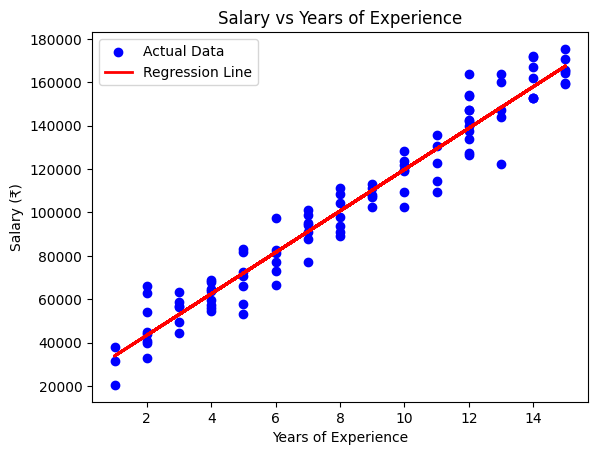

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# STEP 1: Generate Random Dataset
# -----------------------------
np.random.seed(42)  # for reproducibility

# Random years of experience (between 1 and 15 years)
X = np.random.randint(1, 16, 100).reshape(-1, 1)

# Generate salary with linear relation + some random noise
# Equation: Salary = 25000 + 9500 * YearsExperience + random noise
Y = 25000 + 9500 * X.flatten() + np.random.normal(0, 10000, 100)

# Create DataFrame (optional, for visualization)
df = pd.DataFrame({
    "Years_of_Experience": X.flatten(),
    "Salary (₹)": Y.round(2)
})

print("\nSample of the generated dataset:")
print(df.head())

# -----------------------------
# STEP 2: Fit Linear Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, Y)

# Get coefficients
b0 = model.intercept_
b1 = model.coef_[0]

print("\n--- Regression Model Summary ---")
print(f"Intercept (b0): {b0:.2f}")
print(f"Slope (b1): {b1:.2f}")

# -----------------------------
# STEP 3: Make Predictions
# -----------------------------
Y_pred = model.predict(X)

# -----------------------------
# STEP 4: Evaluate the Model
# -----------------------------
r2 = r2_score(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.2f}")

# -----------------------------
# STEP 5: Visualization
# -----------------------------
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', label='Regression Line', linewidth=2)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (₹)")
plt.title("Salary vs Years of Experience")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# STEP 1: Generate Random Dataset
# -----------------------------
np.random.seed(42)  # for reproducibility

# Random house areas (between 800 and 3000 sq. ft.)
X_area = np.random.randint(800, 3001, 100).reshape(-1, 1)

# Generate house prices with linear relation + some random noise
# Equation: Price = 50000 + 150 * Area + random noise
Y_price = 50000 + 150 * X_area.flatten() + np.random.normal(0, 25000, 100)

# Ensure prices are positive
Y_price = np.clip(Y_price, 50000, None)

# Create DataFrame (optional, for visualization)
df_house = pd.DataFrame({
    "Area_sq_ft": X_area.flatten(),
    "House_Price": Y_price.round(2)
})

print("\nSample of the generated house price dataset:")
print(df_house.head())


Sample of the generated house price dataset:
   Area_sq_ft  House_Price
0        1660    295236.65
1        2094    339961.06
2        1930    343262.23
3        1895    331414.47
4        2438    481538.21


In [ ]:
# -----------------------------
# STEP 2: Fit Linear Regression Model
# -----------------------------
model_house = LinearRegression()
model_house.fit(X_area, Y_price)

# Get coefficients
b0_house = model_house.intercept_
b1_house = model_house.coef_[0]

print("\n--- Regression Model Summary (House Price) ---")
print(f"Intercept (b0): {b0_house:.2f}")
print(f"Slope (b1): {b1_house:.2f}")


--- Regression Model Summary (House Price) ---
Intercept (b0): 42203.64
Slope (b1): 154.59


In [ ]:
# -----------------------------
# STEP 3: Make Predictions
# -----------------------------
Y_pred_house = model_house.predict(X_area)

In [ ]:
# -----------------------------
# STEP 4: Evaluate the Model
# -----------------------------
r2_house = r2_score(Y_price, Y_pred_house)
mse_house = mean_squared_error(Y_price, Y_pred_house)

print(f"R² Score (House Price): {r2_house:.3f}")
print(f"Mean Squared Error (House Price): {mse_house:.2f}")

R² Score (House Price): 0.937
Mean Squared Error (House Price): 610323630.38


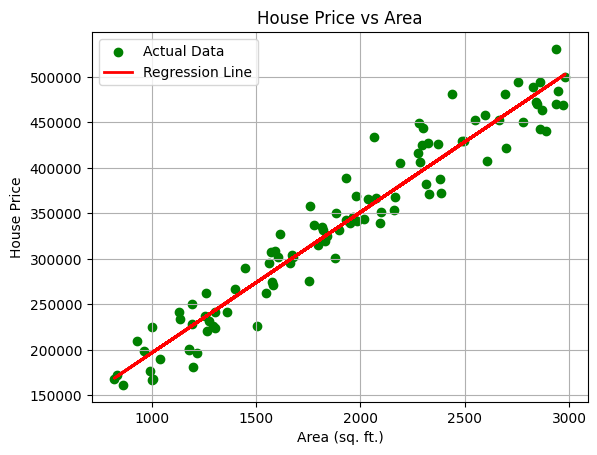

In [ ]:
# -----------------------------
# STEP 5: Visualization
# -----------------------------
plt.scatter(X_area, Y_price, color='green', label='Actual Data')
plt.plot(X_area, Y_pred_house, color='red', label='Regression Line', linewidth=2)
plt.xlabel("Area (sq. ft.)")
plt.ylabel("House Price")
plt.title("House Price vs Area")
plt.legend()
plt.grid(True)
plt.show()

   Temperature   Humidity  WindSpeed   Rainfall
0    32.483571  73.577874   5.216717  52.665517
1    29.308678  75.607845   8.201875  51.063360
2    33.238443  80.830512  10.015731  64.412096
3    37.615149  80.538021  10.140942  64.570161
4    28.829233  56.223306   8.649804  43.010967

R² Score: 0.8349587057092316

Coefficients:
Temperature: -0.3997
Humidity: 0.7145
WindSpeed: 1.3446
Intercept: 1.8230180401754268


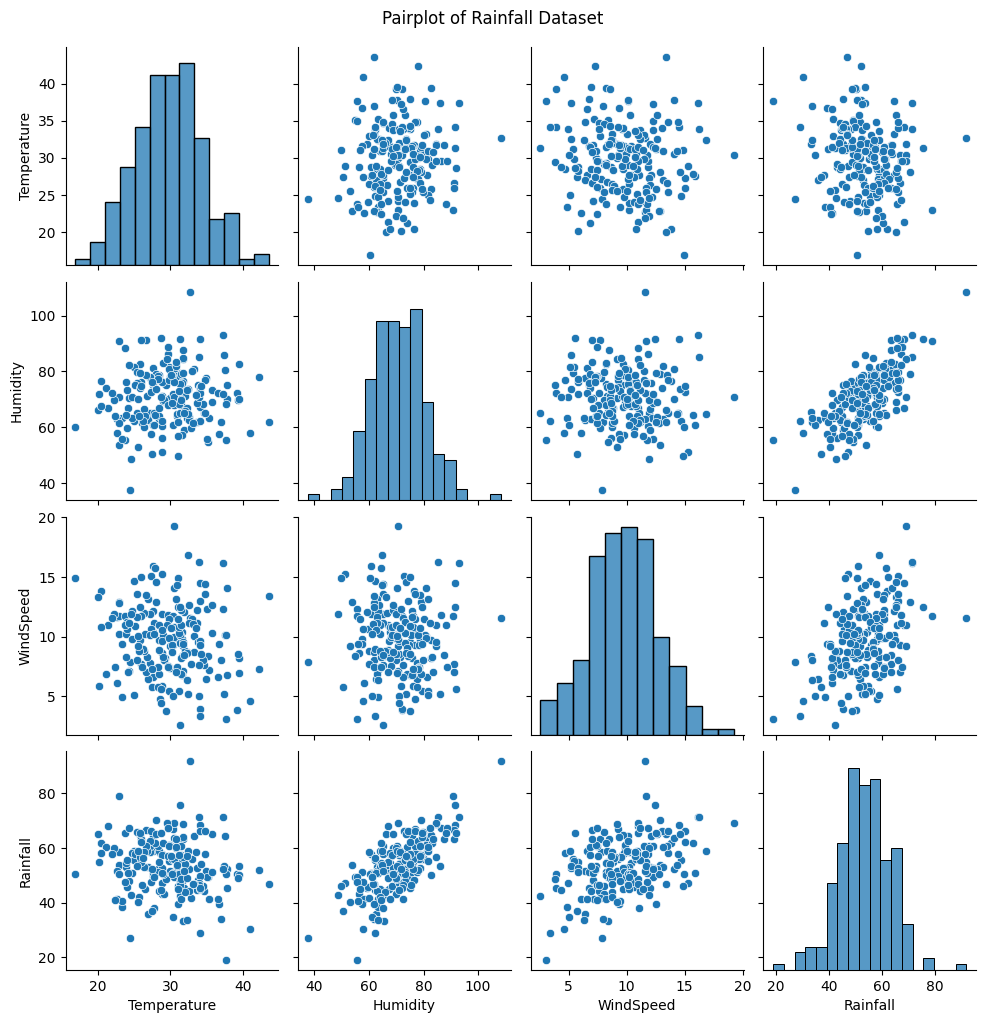

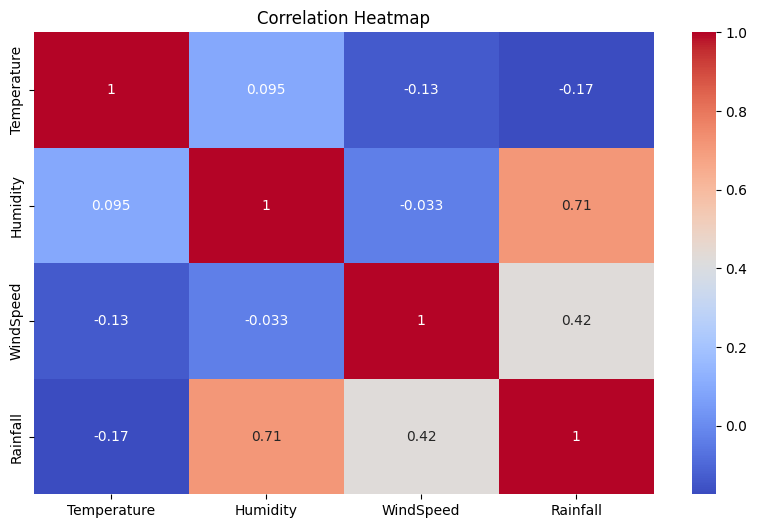

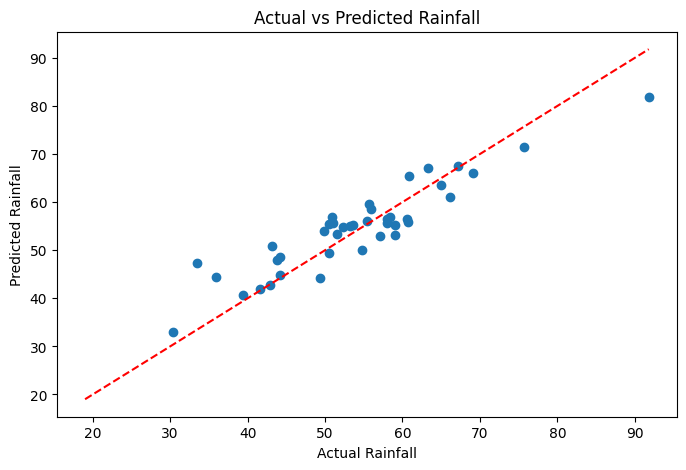

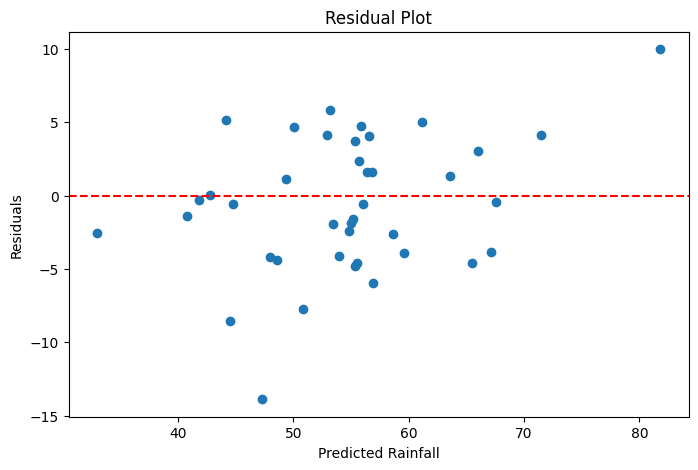

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Step 1: Create random dataset ---
np.random.seed(42)

n = 200

temperature = np.random.normal(30, 5, n)     # avg 30°C
humidity = np.random.normal(70, 10, n)       # avg 70%
wind_speed = np.random.normal(10, 3, n)      # avg 10 km/h

rainfall = (
    0.8 * humidity -
    0.5 * temperature +
    1.2 * wind_speed +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity,
    "WindSpeed": wind_speed,
    "Rainfall": rainfall
})

# ---- Print first 5 rows ----
print(df.head())

# --- Step 2: Split ---
X = df[["Temperature", "Humidity", "WindSpeed"]]
y = df["Rainfall"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train Model ---
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nR² Score:", r2_score(y_test, y_pred))

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print("Intercept:", model.intercept_)

# --------------------------------------------------------
#       📊 VISUALISATIONS
# --------------------------------------------------------

# 1️⃣ Pairplot
sns.pairplot(df)
plt.suptitle("Pairplot of Rainfall Dataset", y=1.02)
plt.show()

# 2️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 3️⃣ Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')   # perfect line
plt.show()

# 4️⃣ Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rainfall")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
